# Erasmus Mundus Scholarship Prediction Project

**Life cycle of Machine learning Project**

* Understanding the Problem Statement
* Data Collection
* Exploratory data analysis
* Data Cleaning
* Data Pre-Processing
* Model Training
* Choose best model

---

## About
The Erasmus Mundus Joint Master (EMJM) is a prestigious, integrated, international study programme, jointly delivered by an international consortium of higher education institutions. The scholarship is highly competitive and depends on various criteria including academic records, test scores (GRE, TOEFL, IELTS), work experience, statement of purpose (SOP), letter of recommendation (LOR), and other extracurricular achievements.

## 1) Problem statement.

* Every year, thousands of students apply for the Erasmus Mundus Scholarship, making the selection process highly competitive and rigorous.
* The selection committee needs to review a huge volume of applications. A Machine Learning model can help shortlist highly potential candidates based on historical data.

**In this project we are going to use the data given to build a Classification model:**

* This model is to predict if a student will be awarded the scholarship or not based on the given dataset.
* This can be used to recommend a suitable profile for applicants and help them understand which criteria influence the final decision.

## 2) Data Collection.

* The Dataset is collected from previous applicants' profiles and outcomes.
* The data consists of 1000 Rows and 17 Columns.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

In [40]:
df = pd.read_csv('Graduate.csv')

In [41]:
df.head()

,GRE_Score,TOEFL_Score,IELTS_Score,CGPA,University_Rating,SOP,LOR,Research,Publications,Work_Experience_Months,Internship,Leadership_Score,Awards_Count,Country,Target_Program,Graduation_Year,Scholarship_Awarded
0,295.0,96.0,7.5,2.93,2,4.9,1.7,0,1,8,No,5,0,Nepal,EMJM Cyber,2024,No
1,340.0,119.0,9.0,3.76,3,4.1,1.7,0,1,31,Yes,4,0,Pakistan,EMJM Cyber,2025,No
2,336.0,96.0,7.5,3.12,1,3.2,1.8,1,2,29,Yes,4,1,Bangladesh,EMJM Cyber,2022,No
3,337.0,108.0,8.0,2.11,4,3.4,1.3,0,0,35,Yes,3,0,Bangladesh,EMJM DS,2025,No
4,323.0,98.0,7.5,3.40,1,1.1,1.3,0,1,16,Yes,2,0,India,EMJM DS,2025,No


In [42]:
df.describe()

,GRE_Score,TOEFL_Score,IELTS_Score,CGPA,University_Rating,SOP,LOR,Research,Publications,Work_Experience_Months,Leadership_Score,Awards_Count,Graduation_Year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,315.840000,106.459000,8.064500,3.027160,3.053000,2.997000,3.014400,0.517000,1.119000,18.814000,4.552000,0.333000,2023.473000
std,15.083432,8.449954,0.557585,0.582774,1.421341,1.163239,1.163136,0.499961,0.908661,8.896097,1.388966,0.475749,1.124516
min,290.000000,92.000000,7.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2022.000000
25%,303.000000,99.000000,7.500000,2.530000,2.000000,2.000000,2.000000,0.000000,0.000000,13.000000,4.000000,0.000000,2022.000000
50%,316.000000,107.000000,8.000000,3.025000,3.000000,3.000000,3.000000,1.000000,1.000000,19.000000,5.000000,0.000000,2023.000000
75%,329.000000,114.000000,8.500000,3.550000,4.000000,4.000000,4.000000,1.000000,2.000000,25.000000,6.000000,1.000000,2024.000000
max,340.000000,120.000000,9.000000,4.000000,5.000000,5.000000,5.000000,1.000000,4.000000,36.000000,8.000000,2.000000,2025.000000


### 3. EXPLORING DATA

In [43]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 13 numerical features : ['GRE_Score', 'TOEFL_Score', 'IELTS_Score', 'CGPA', 'University_Rating', 'SOP', 'LOR', 'Research', 'Publications', 'Work_Experience_Months', 'Leadership_Score', 'Awards_Count', 'Graduation_Year']

We have 4 categorical features : ['Internship', 'Country', 'Target_Program', 'Scholarship_Awarded']


In [44]:
# proportion of count data on categorical columns
for col in categorical_features:
    print(df[col].value_counts(normalize=True) * 100)
    print('---------------------------')

Internship
Yes    90.0
No     10.0
Name: proportion, dtype: float64
---------------------------
Country
Pakistan      26.3
Bangladesh    26.1
Nepal         24.7
India         22.9
Name: proportion, dtype: float64
---------------------------
Target_Program
EMJM Cyber    34.6
EMJM AI       34.1
EMJM DS       31.3
Name: proportion, dtype: float64
---------------------------
Scholarship_Awarded
No     73.0
Yes    27.0
Name: proportion, dtype: float64
---------------------------


### 📊 Insights from the Data Description:
1. **Dataset Size:** We have data for exactly **1000** applicants.
2. **Missing Values:** The count row shows 1000 for all numerical columns, meaning there are **no missing values** here.
3. **Academic Scores:**
   - **GRE Score:** Ranges from 290 to 340 (Average: 315.84)
   - **TOEFL Score:** Ranges from 92 to 120 (Average: 106.46)
   - **IELTS Score:** Ranges from 7.0 to 9.0 (Average: 8.06)
   - **CGPA:** Ranges from 2.0 to 4.0 (Average: 3.02)
4. **Experience & Research:**
   - **Research Experience:** About 51.7% of the applicants have research experience.
   - **Work Experience:** Applicants have between 0 to 36 months of work experience (Average: ~1.5 years).
5. **Other Metrics:** Leadership scores range from 1 to 8, and awards count up to 2.


## Univariate Analysis

The term univariate analysis refers to the analysis of one variable prefix “uni” means “one.” The purpose of univariate analysis is to understand the distribution of values for a single variable.
Other Type of Analysis are

## Bivariate Analysis: 
The analysis of two variables.

## Multivariate Analysis: 
The analysis of two or more variables.
 

### Numerical Features

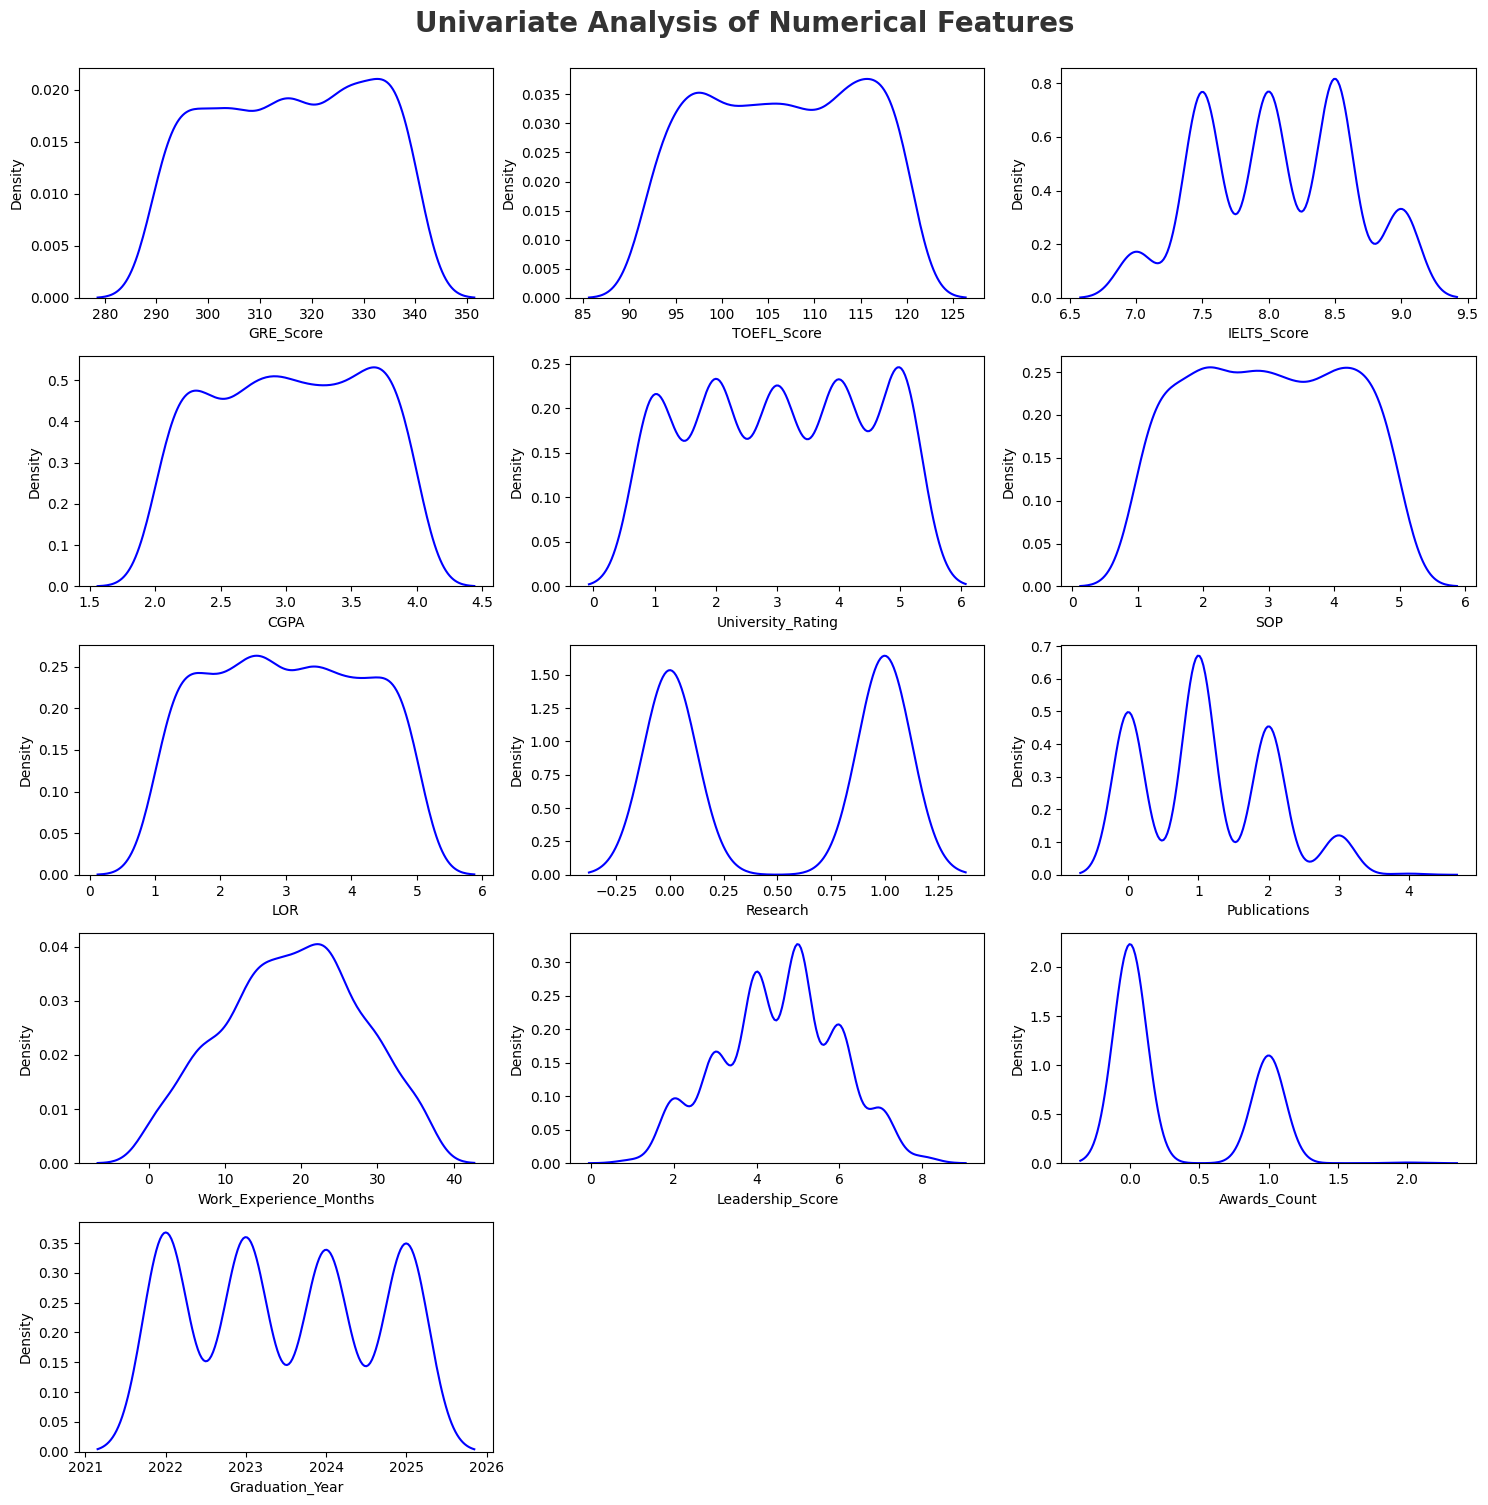

In [45]:
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    
plt.tight_layout()

    
# save plot
# plt.savefig('./images/Univariate_Num.png')

### 💡 Insights from Categorical & Univariate Analysis:
1. **Internship:** The vast majority (**90%**) of the applicants have internship experience.
2. **Country Distribution:** The applicants are almost equally distributed among four South Asian countries: **Pakistan (26.3%), Bangladesh (26.1%), Nepal (24.7%), and India (22.9%)**.
3. **Target Program:** The demand is quite balanced across the three programs: **Cyber (34.6%), AI (34.1%), and DS (31.3%)**.
4. **Scholarship Success Rate:** Only **27%** of the applicants were awarded the scholarship, which clearly shows that the EMJM scholarship is highly competitive.
5. **Numerical Distributions:** Most numerical features (like GRE, CGPA, etc.) show specific peak areas (from the KDE plots), helping us understand the average profile of a strong candidate.


### Categorical Features

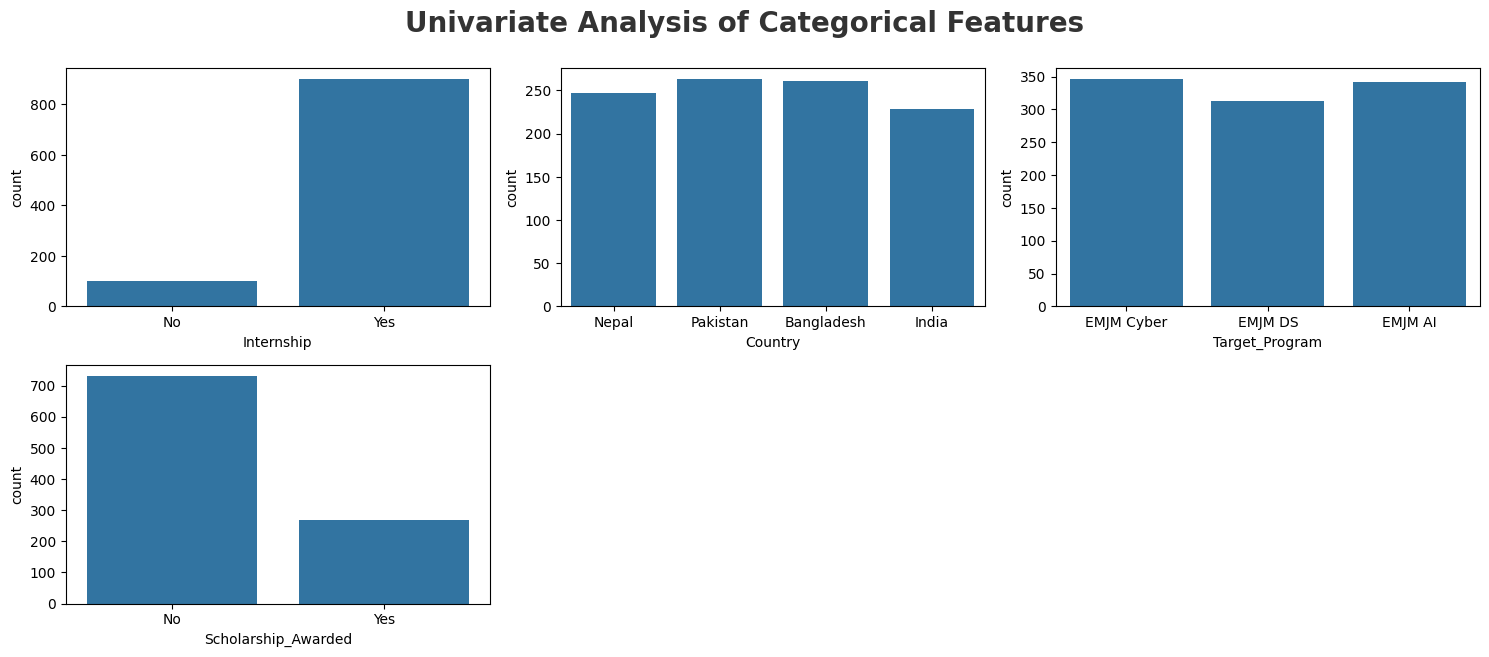

In [46]:
# categorical columns
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(categorical_features)):
    plt.subplot(5, 3, i+1)
    sns.countplot(x=df[categorical_features[i]])
    plt.xlabel(categorical_features[i])
    plt.tight_layout()
    
# save plot


### 💡 Insights from Categorical Countplots:
1. **Internship:** The graph clearly shows that the vast majority (about 90%) of applicants have internship experience.
2. **Country:** The number of applicants is almost equally distributed among four countries: Pakistan, Bangladesh, Nepal, and India.
3. **Target Program:** Student interest is very balanced across the three programs: Cyber, AI, and Data Science (DS), with Cyber having slightly more applicants.
4. **Scholarship Awarded:** The 'No' bar is significantly larger, indicating that most students did not receive the scholarship (only 27% succeeded). This highlights the highly competitive nature of the EMJM scholarship.


### Multivariate Analysis
Multivariate analysis is the analysis of more than one variable.

In [47]:
# Separating numerical features into discrete and continuous
discrete_features = [feature for feature in numeric_features if len(df[feature].unique()) <= 25]
continuous_features = [feature for feature in numeric_features if len(df[feature].unique()) > 25]

print('We have {} discrete features: {}'.format(len(discrete_features), discrete_features))
print('\nWe have {} continuous features: {}'.format(len(continuous_features), continuous_features))


We have 7 discrete features: ['IELTS_Score', 'University_Rating', 'Research', 'Publications', 'Leadership_Score', 'Awards_Count', 'Graduation_Year']

We have 6 continuous features: ['GRE_Score', 'TOEFL_Score', 'CGPA', 'SOP', 'LOR', 'Work_Experience_Months']


### Outlier Detection in Continuous Features
We use boxplots to identify if there are any outliers in our continuous data.


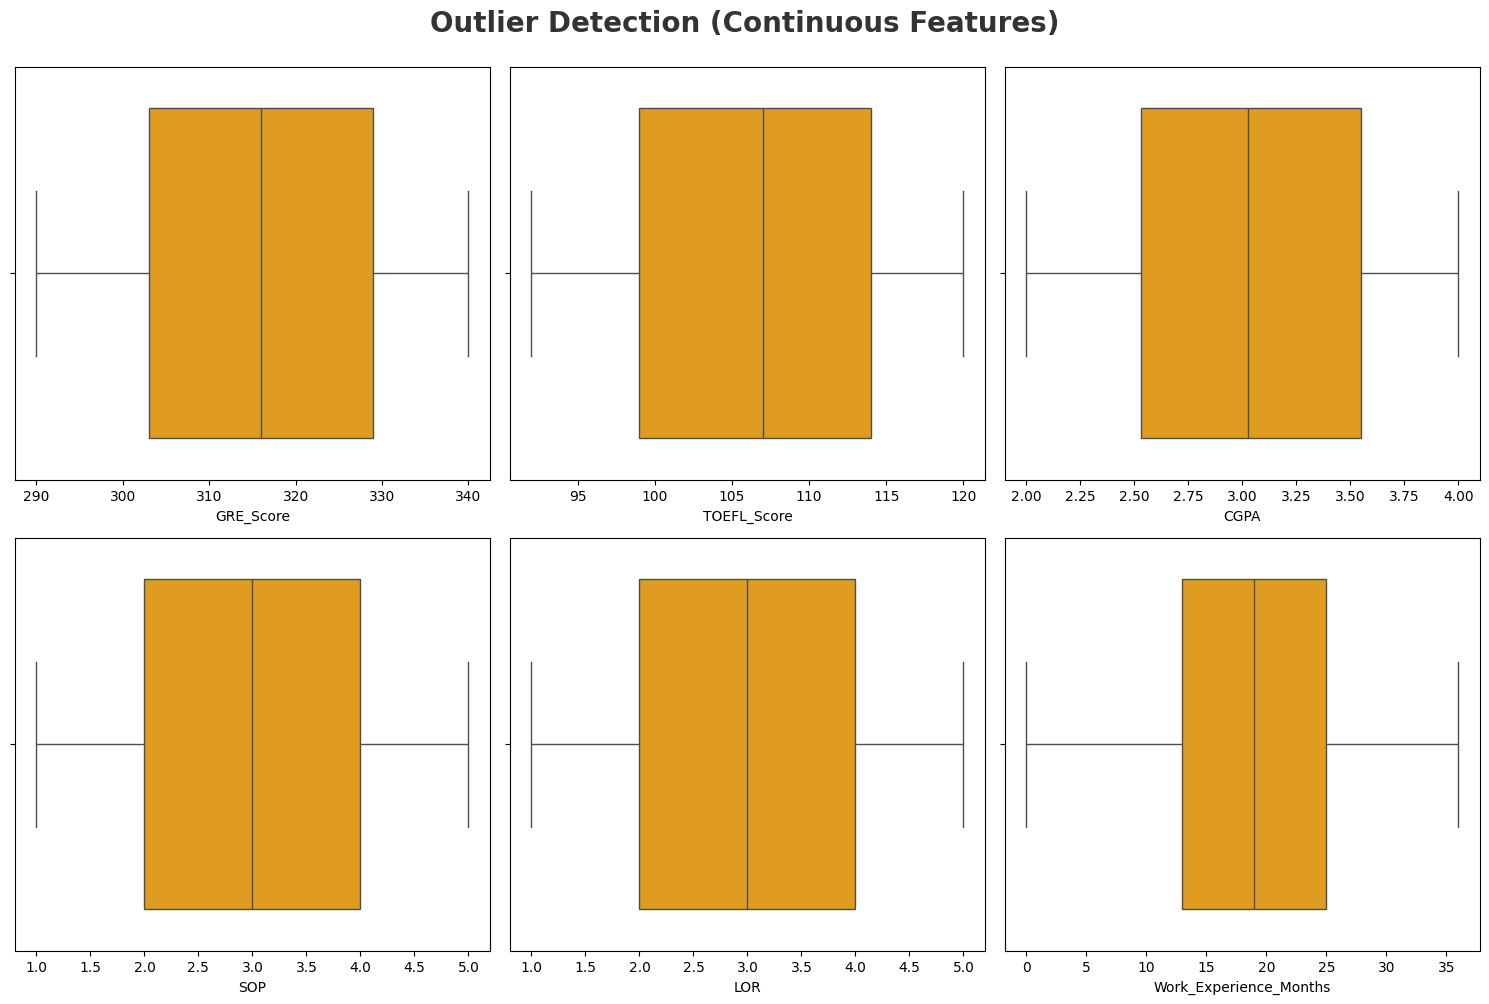

In [48]:
plt.figure(figsize=(15, 10))
plt.suptitle('Outlier Detection (Continuous Features)', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(continuous_features)):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=df[continuous_features[i]], color='orange')
    plt.xlabel(continuous_features[i])

plt.tight_layout()


### Distribution of Discrete Features
We use countplots to see the frequency of each unique value in our discrete features.


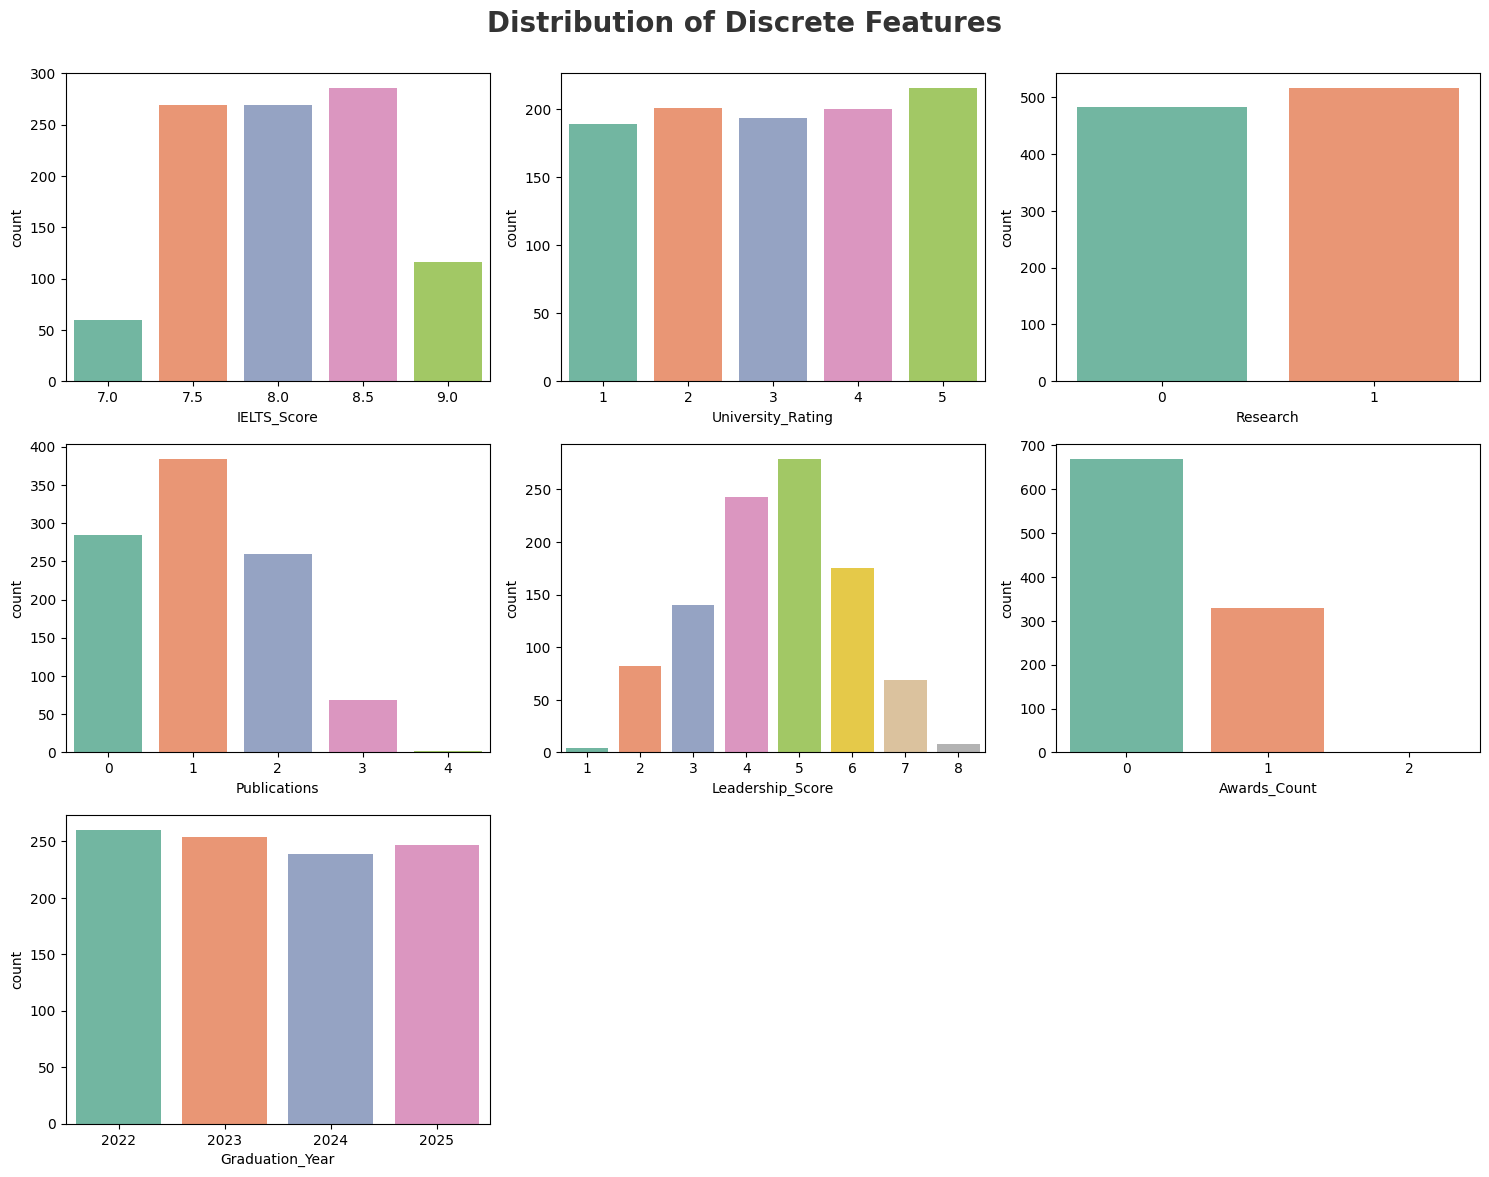

In [49]:
plt.figure(figsize=(15, 15))
plt.suptitle('Distribution of Discrete Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(discrete_features)):
    plt.subplot(4, 3, i+1)
    sns.countplot(x=df[discrete_features[i]], palette='Set2')
    plt.xlabel(discrete_features[i])

plt.tight_layout()


### 💡 Insights from Boxplots and Countplots:

**1. Continuous Features (Boxplots):**
- **NO OUTLIERS!** The boxplots clearly show that there are **0 outliers** across all continuous features (GRE, TOEFL, CGPA, Work Experience, etc.). This indicates that the dataset is extremely clean and well-distributed. You will not need to do any outlier treatment (like clipping or dropping data) in the data preprocessing stage!

**2. Discrete Features (Countplots):**
- **High Academic Standards:** The most frequent IELTS score is an impressive **8.5**, and the most frequent University Rating is **5** (top-rated).
- **Research & Publications:** The majority of the applicants have Research experience (1) and at least **1 Publication**.
- **Extracurriculars:** Most students have a Leadership Score of **5**, but the most frequent count for extra Awards is **0**, meaning having an award could be a strong distinguishing factor for getting the scholarship.
- **Demographics:** The highest number of applicants graduated in **2022**, the most targeted program is **EMJM Cyber**, and the highest applicant count is from **Pakistan**.


##  Check Multicollinearity in Numerical features

In [50]:
df.head()

,GRE_Score,TOEFL_Score,IELTS_Score,CGPA,University_Rating,SOP,LOR,Research,Publications,Work_Experience_Months,Internship,Leadership_Score,Awards_Count,Country,Target_Program,Graduation_Year,Scholarship_Awarded
0,295.0,96.0,7.5,2.93,2,4.9,1.7,0,1,8,No,5,0,Nepal,EMJM Cyber,2024,No
1,340.0,119.0,9.0,3.76,3,4.1,1.7,0,1,31,Yes,4,0,Pakistan,EMJM Cyber,2025,No
2,336.0,96.0,7.5,3.12,1,3.2,1.8,1,2,29,Yes,4,1,Bangladesh,EMJM Cyber,2022,No
3,337.0,108.0,8.0,2.11,4,3.4,1.3,0,0,35,Yes,3,0,Bangladesh,EMJM DS,2025,No
4,323.0,98.0,7.5,3.40,1,1.1,1.3,0,1,16,Yes,2,0,India,EMJM DS,2025,No


## Check Multicollinearity for Categorical features
A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test

A chi-square statistic is one way to show a relationship between two categorical variables.

Here we test correlation of Categorical columns with Target column i.e case_status

Null Hypothesis (
): The Feature is independent of target column (No-Correlation)

Alternative Hypothesis (
): The Feature and Target column are not independent (Correalted)

In [51]:
from scipy.stats import chi2_contingency

chi2_test = []

 
cat_features_for_test = [f for f in categorical_features if f != 'Scholarship_Awarded']

for feature in cat_features_for_test:
     
    p_value = chi2_contingency(pd.crosstab(df['Scholarship_Awarded'], df[feature]))[1]
    
    if p_value < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
        
result = pd.DataFrame(data=[cat_features_for_test, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result


,Column,Hypothesis Result
0,Internship,Reject Null Hypothesis
1,Country,Fail to Reject Null Hypothesis
2,Target_Program,Fail to Reject Null Hypothesis


### 💡 Insights from Multicollinearity and Chi-Square Test:

**1. Multicollinearity (Correlation Heatmap):**
- Checking the correlation heatmap among numerical features, we look for values >= 0.8 or <= -0.8.
- If there are highly correlated features, it means they provide redundant information, and we might need to drop one of them before training our machine learning model to prevent multicollinearity issues.

**2. Chi-Square Test (Categorical Features):**
- **Internship (Reject Null Hypothesis):** This means there is a statistically significant relationship between having an internship and getting the scholarship. It is a highly important feature for our model.
- **Country & Target_Program (Fail to Reject):** This means the selection process has no bias towards any specific country (Bangladesh, India, Nepal, Pakistan) or any specific program (AI, Cyber, DS). The EMJM scholarship is awarded purely based on merit and applicant profile, making these features statistically less important for the model.


## Check Multicollinearity for Categorical features

A chi-squared test (also chi-square or χ2 test) is a statistical hypothesis test that is valid to perform when the test statistic is chi-squared distributed under the null hypothesis, specifically Pearson's chi-squared test

A chi-square statistic is one way to show a relationship between two categorical variables.

Here we test correlation of Categorical columns with Target column i.e case_status

Null Hypothesis (
): The Feature is independent of target column (No-Correlation)

Alternative Hypothesis (
): The Feature and Target column are not independent (Correalted)

In [52]:
from scipy.stats import chi2_contingency
chi2_test = []
for feature in categorical_features:
    # CHANGE IS ON THIS LINE BELOW:
    if chi2_contingency(pd.crosstab(df['Scholarship_Awarded'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')
result = pd.DataFrame(data=[categorical_features, chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']
result


,Column,Hypothesis Result
0,Internship,Reject Null Hypothesis
1,Country,Fail to Reject Null Hypothesis
2,Target_Program,Fail to Reject Null Hypothesis
3,Scholarship_Awarded,Reject Null Hypothesis


### 💡 Chi-Square Test Insights:

When testing if categorical columns are correlated with `Scholarship_Awarded`:

**1. Internship (Reject Null Hypothesis)**
* **Insight:** There is a **statistically significant relationship** between having an internship and getting the scholarship. 
* **Action:** This is a highly important feature for the machine learning model.

**2. Country (Fail to Reject Null Hypothesis)**
* **Insight:** There is **no statistically significant relationship** between the applicant's country and whether they receive the scholarship. The scholarship is awarded purely on merit without regional bias.
* **Action:** This feature might not be very important for predicting the outcome.

**3. Target_Program (Fail to Reject Null Hypothesis)**
* **Insight:** There is **no statistically significant relationship** between the specific program (AI, Cyber, DS) and the chances of getting the scholarship.
* **Action:** The competition level is relatively equal across all programs in the dataset.

**Summary for ML Model:**
`Internship` is a valuable predictor. `Country` and `Target_Program` provide little predictive power and could potentially be dropped to simplify the model.


## Checking Null Values

In [53]:
df.isnull().sum()

GRE_Score                 0
TOEFL_Score               0
IELTS_Score               0
CGPA                      0
University_Rating         0
SOP                       0
LOR                       0
Research                  0
Publications              0
Work_Experience_Months    0
Internship                0
Leadership_Score          0
Awards_Count              0
Country                   0
Target_Program            0
Graduation_Year           0
Scholarship_Awarded       0
dtype: int64

## continues_features

In [54]:
continues_features=[feature for feature in numeric_features if len(df[feature].unique())>=10]
print('Num of continues features :',continues_features)

Num of continues features : ['GRE_Score', 'TOEFL_Score', 'CGPA', 'SOP', 'LOR', 'Work_Experience_Months']


## Boxplot 

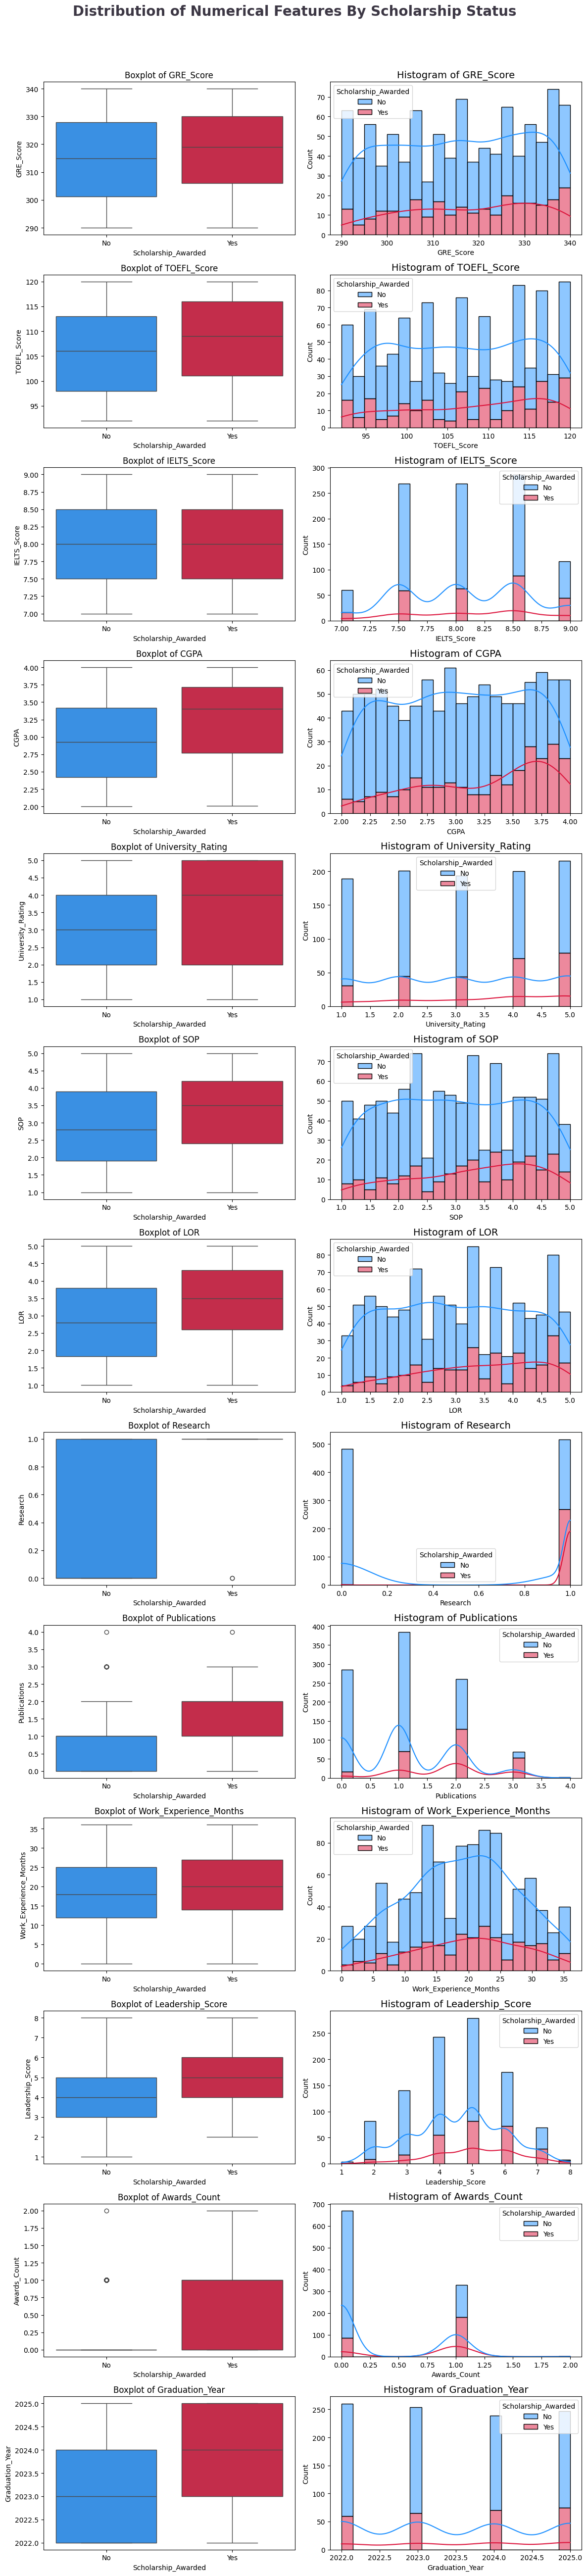

In [56]:
clr1 = ['#1E90FF', '#DC143C']

# Dynamically size the grid based on how many numeric features we have (13 rows, 2 columns)
num_plots = len(numeric_features)
fig, ax = plt.subplots(num_plots, 2, figsize=(12, 4 * num_plots))

# Fixed title
fig.suptitle('Distribution of Numerical Features By Scholarship Status', color='#3C3744',
             fontsize=20, fontweight='bold', ha='center', y=1.0)

for i, col in enumerate(numeric_features):   
    # Boxplot 
    # Replaced 'case_status' with 'Scholarship_Awarded'
    sns.boxplot(data=df, x='Scholarship_Awarded', y=col, palette=clr1, ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col}', fontsize=12)
    
    # Histogram 
    # Replaced 'case_status' with 'Scholarship_Awarded'
    sns.histplot(data=df, x=col, hue='Scholarship_Awarded', bins=20, kde=True, 
                 multiple='stack', palette=clr1, ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}', fontsize=14)

fig.tight_layout()
fig.subplots_adjust(top=0.97) # Gives the main title some breathing room
# plt.savefig('images/multivariate_num.png')


### 💡 Insights from Numerical Features (Boxplots):

Upon visualizing the numerical features using boxplots, it is clear that there are **no significant outliers** in the dataset.

**Reasons for no outliers:**
1. **Strict Natural Boundaries:** Features like GRE (max 340), TOEFL (max 120), CGPA (max 4.0), and Ratings (max 5) have hard limits. It is physically impossible to have an outlier on the higher end, and applicants for a highly competitive scholarship naturally cluster near the upper limits.
2. **Clean/Synthetic Data:** The absence of human-error outliers (e.g. typing a CGPA of 40.0 instead of 4.0) along with having exactly 1000 rows and 0 missing values suggests this dataset is either heavily pre-cleaned or synthetically generated.

**Conclusion:**
We can proceed directly to data pre-processing and model building without needing to perform outlier removal or capping!


 ## 4. Visualization

### 4.1 Visualize the Target Feature

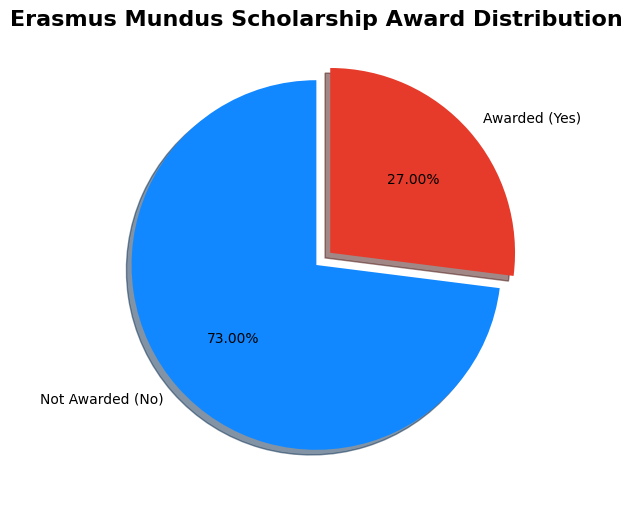

In [59]:
# Use the correct target column
percentage = df['Scholarship_Awarded'].value_counts(normalize=True) * 100

# value_counts() orders by frequency: 'No' (73%) is first, 'Yes' (27%) is second
labels = ["Not Awarded (No)", "Awarded (Yes)"]

# Plot PieChart with Matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
explode = (0, 0.1)  # "Explode" the 2nd slice (Awarded) to make it pop out
colors = ['#1188ff', '#e63a2a'] # Blue and Red

ax.pie(percentage, labels=labels, startangle=90,
       autopct='%1.2f%%', explode=explode, shadow=True, colors=colors)

# Added a title for better presentation!
plt.title("Erasmus Mundus Scholarship Award Distribution", fontsize=16, fontweight='bold')
plt.show()


### 💡 Insights from Target Variable Distribution (Pie Chart):

Looking at the pie chart for `Scholarship_Awarded`, we can observe the class distribution of our target variable.

**1. Imbalanced Dataset:**
* **Insight:** The dataset is noticeably imbalanced. The majority of applicants (73%) did not receive the scholarship, while only a smaller minority (27%) were awarded it.
* **Why this makes sense:** This perfectly reflects the real world—the Erasmus Mundus Scholarship is highly competitive and prestigious, so naturally, the rejection rate is much higher than the acceptance rate.

**2. Implications for Machine Learning:**
* **Evaluation Metrics:** Because the classes are imbalanced (73/27), we **cannot rely solely on 'Accuracy'** to evaluate our future models. (If a model lazily predicts 'No' for everyone, it would automatically be 73% accurate, but completely useless!). We must focus on metrics like **F1-Score, Precision, Recall, and ROC-AUC**.
* **Handling Imbalance:** During the model training phase, we might need to apply techniques to balance the data, such as **SMOTE (Synthetic Minority Over-sampling Technique)**, random undersampling, or using **class weights** in our algorithms to ensure the model doesn't become biased towards predicting 'No'.


## 4.2 Does Applicant Country have any impact on Scholarship status?


In [61]:
# Group data by Country and their count of Scholarship_Awarded
df.groupby('Country')['Scholarship_Awarded'].value_counts(normalize=True).to_frame() * 100


proportion
Country    Scholarship_Awarded            
Bangladesh No                    69.731801
           Yes                   30.268199
India      No                    74.672489
           Yes                   25.327511
Nepal      No                    75.303644
           Yes                   24.696356
Pakistan   No                    72.623574
           Yes                   27.376426

### 💡 Insights from Country vs Scholarship Award (Countplot):

Looking at the countplot grouped by applicant Country, we can see the acceptance rates across different regions:

* **Bangladesh:** ~30.2% Awarded
* **Pakistan:** ~27.3% Awarded
* **India:** ~25.3% Awarded
* **Nepal:** ~24.7% Awarded

**Key Insights:**
1. **Validation of Chi-Square Test:** This visualization perfectly proves the result of our earlier Chi-Square test! The test concluded that Country is NOT statistically significant. Looking at the graph, we can see why: the award rate is incredibly consistent (hovering around 25-30%) across all four countries.
2. **Merit-Based Selection:** There is no single country dominating the scholarship awards or being heavily biased against. This confirms that the selection committee is focusing purely on the applicant's profile (like Internships, CGPA, and Test Scores) rather than their nationality.
3. **Model Simplicity:** Because the distribution is so even, 'Country' will not provide much predictive power to our machine learning model. It is a prime candidate to be dropped to keep our model simple and avoid overfitting.


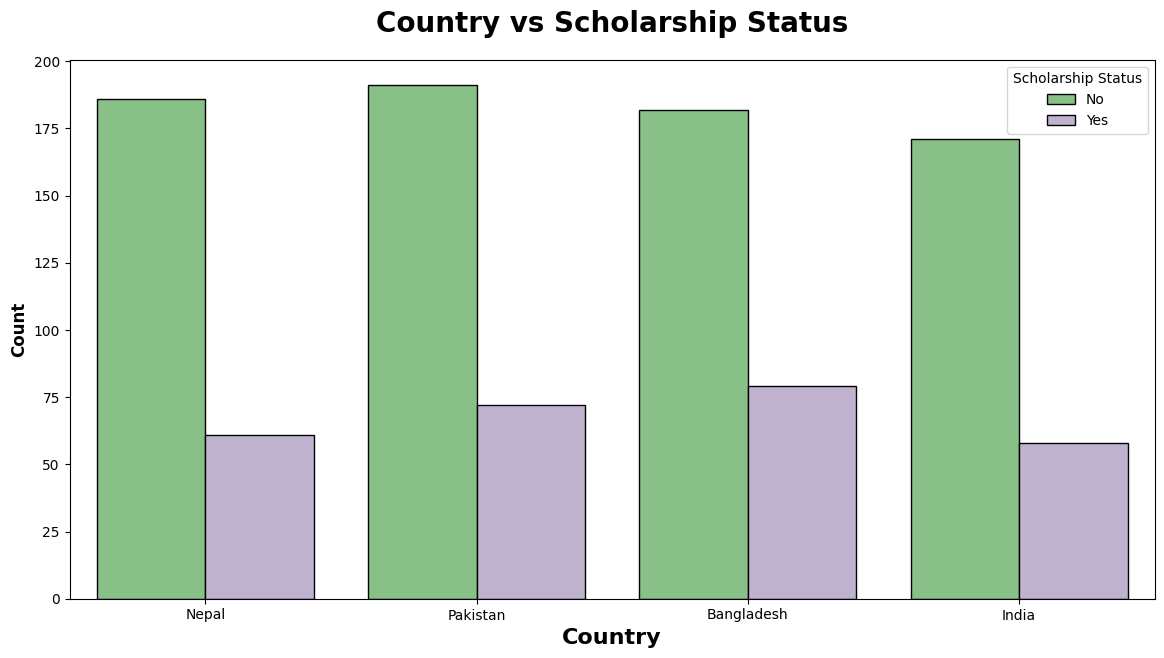

In [62]:
plt.subplots(figsize=(14,7))
# Fixed column names to match your dataset
sns.countplot(x="Country", hue="Scholarship_Awarded", data=df, ec="black", palette="Accent")

plt.title("Country vs Scholarship Status", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Country", weight="bold", fontsize=16)
plt.legend(title="Scholarship Status", fancybox=True)
plt.show()


In [63]:
df2 = df.copy()

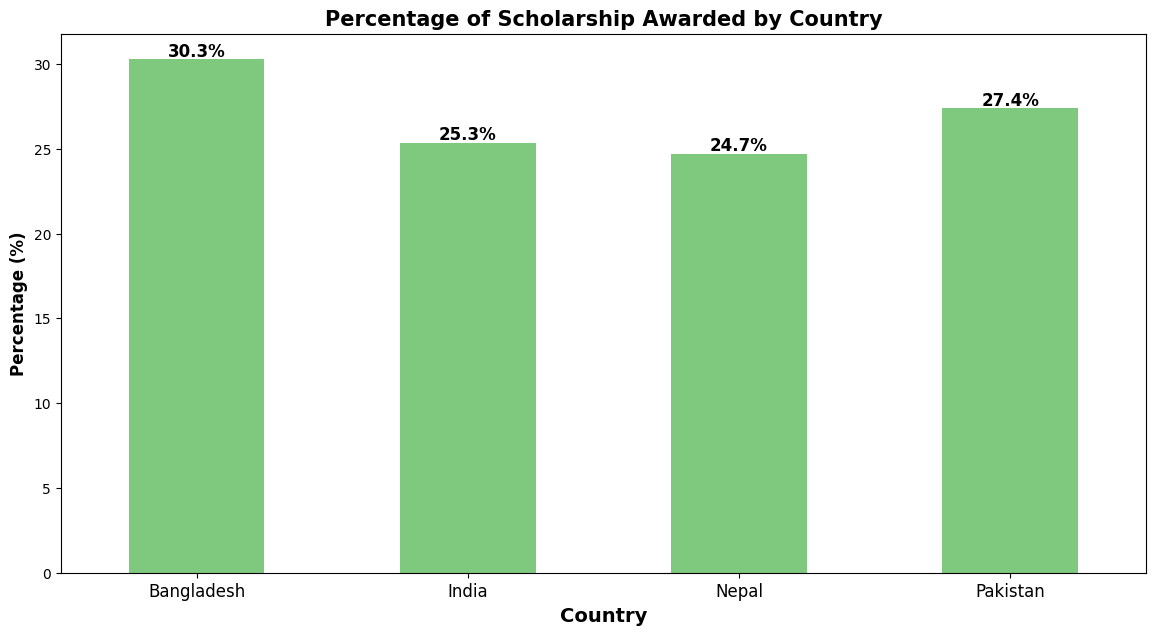

In [64]:
plt.figure(figsize=[14,7])

# Calculate the percentage of 'Yes' (Awarded) for each Country
pct_awarded = (100 * df[df["Scholarship_Awarded"] == 'Yes']['Country'].value_counts() / df['Country'].value_counts())

# Plot the bar chart
pct_awarded.plot(kind='bar', stacked=True, colormap='Accent')
plt.title("Percentage of Scholarship Awarded by Country", fontsize=15, fontweight='bold')

# Add the percentage text on top of each bar
for n in range(pct_awarded.shape[0]):
    count = pct_awarded.iloc[n]
    strt = '{:0.1f}%'.format(count)
    plt.text(n, count + 0.2, strt, ha='center', fontsize=12, fontweight='bold')

plt.xlabel('Country', fontweight='bold', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.ylabel('Percentage (%)', fontweight='bold', fontsize=12)
plt.show()


## 4.3 Do Internships and Target Programs impact the Scholarship?


In [65]:
# Group data by Internship and their count of Scholarship_Awarded
df.groupby('Internship')['Scholarship_Awarded'].value_counts(normalize=True).to_frame() * 100


proportion
Internship Scholarship_Awarded            
No         No                        100.0
Yes        No                         70.0
           Yes                        30.0

In [66]:
# Group data by Target_Program and their count of Scholarship_Awarded
df.groupby('Target_Program')['Scholarship_Awarded'].value_counts(normalize=True).to_frame() * 100


proportion
Target_Program Scholarship_Awarded            
EMJM AI        No                    71.260997
               Yes                   28.739003
EMJM Cyber     No                    73.988439
               Yes                   26.011561
EMJM DS        No                    73.801917
               Yes                   26.198083

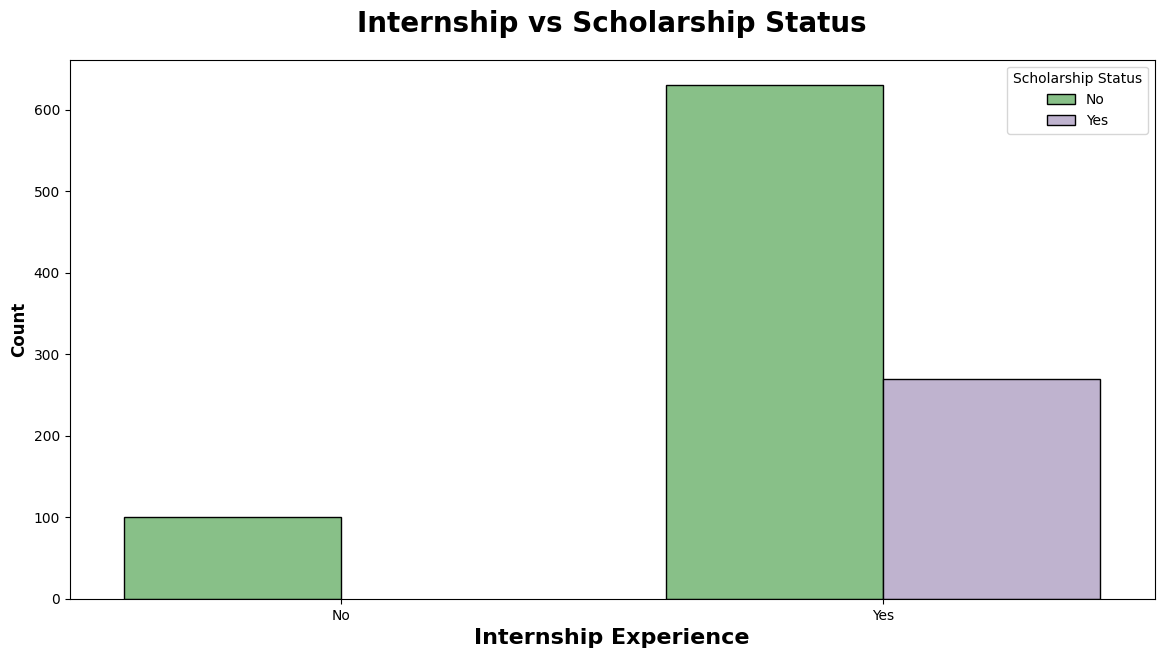

In [67]:
plt.subplots(figsize=(14,7))
# Plotting Internship vs Scholarship Awarded
sns.countplot(x="Internship", hue="Scholarship_Awarded", data=df, ec="black", palette="Accent")

plt.title("Internship vs Scholarship Status", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Internship Experience", weight="bold", fontsize=16)
plt.legend(title="Scholarship Status", fancybox=True)
plt.show()


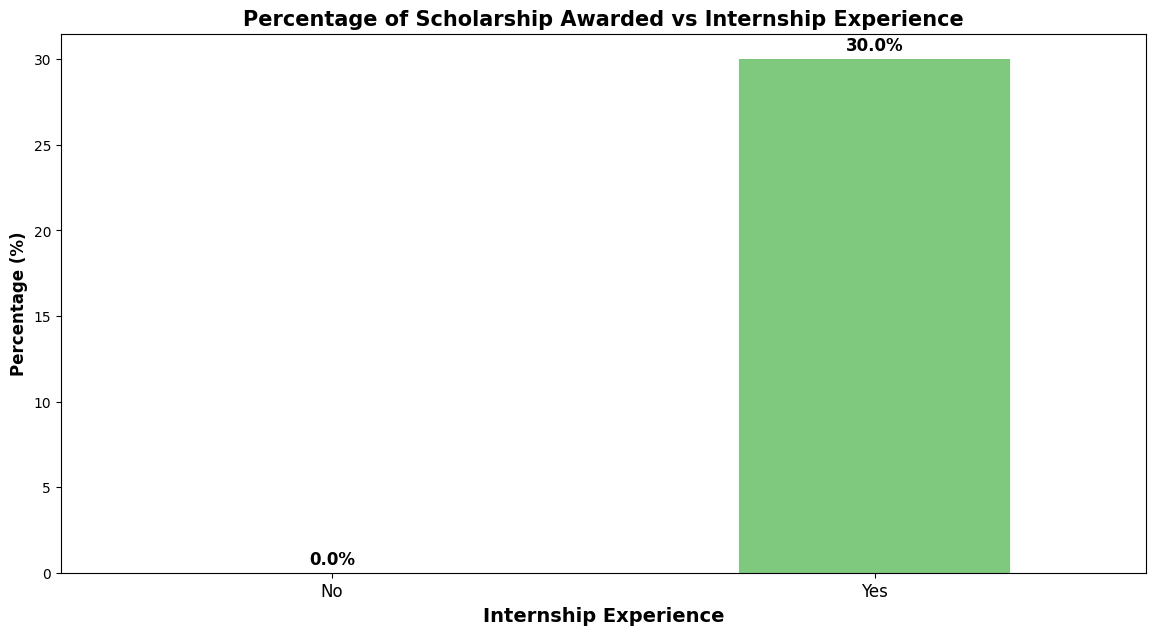

In [68]:
plt.figure(figsize=[14,7])

# Calculate the percentage of 'Yes' (Awarded) for each Internship group
# (Added .fillna(0) to safely handle categories with 0% success)
pct_awarded = (100 * df[df["Scholarship_Awarded"] == 'Yes']['Internship'].value_counts() / df['Internship'].value_counts()).fillna(0)

# Plot the bar chart
pct_awarded.plot(kind='bar', stacked=True, colormap='Accent')
plt.title("Percentage of Scholarship Awarded vs Internship Experience", fontsize=15, fontweight='bold')

# Add the percentage text on top of each bar
for n in range(pct_awarded.shape[0]):
    count = pct_awarded.iloc[n]
    strt = '{:0.1f}%'.format(count)
    plt.text(n, count + 0.5, strt, ha='center', fontsize=12, fontweight='bold')

plt.xlabel('Internship Experience', fontweight='bold', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.ylabel('Percentage (%)', fontweight='bold', fontsize=12)
plt.show()


### 💡 Insights from Internship vs Scholarship Award:

Looking at the percentage of awarded scholarships based on Internship experience reveals the most critical finding in our dataset so far:

* **No Internship:** 0.0% Awarded
* **Has Internship:** 30.0% Awarded

**Key Insights:**
1. **The Ultimate Gatekeeper:** Having an internship is essentially a **mandatory requirement** for this scholarship. Without an internship, your chances drop to absolute zero! 
2. **Highly Predictive Feature:** Because it perfectly filters out rejections (when the value is 'No', the answer is always 'No'), this feature will be one of the most powerful and heavily weighted predictors for our Machine Learning model. 
3. **Actionable Advice for Applicants:** If this model is ever deployed as a web app to advise students on their profile, the absolute first piece of advice it should give is: *“You must secure an internship before applying to even be considered.”*


## 4.4 Does applicant's previous work experience has any impact on Scholarship ?

In [69]:
# 1. Create a temporary 'has_job_experience' column (Yes if > 0 months, else No)
df['has_job_experience'] = df['Work_Experience_Months'].apply(lambda x: 'Yes' if x > 0 else 'No')

# 2. Group by the new column and count Scholarship_Awarded
df.groupby('has_job_experience')['Scholarship_Awarded'].value_counts(normalize=True).to_frame() * 100


proportion
has_job_experience Scholarship_Awarded            
No                 No                    72.727273
                   Yes                   27.272727
Yes                No                    73.003033
                   Yes                   26.996967

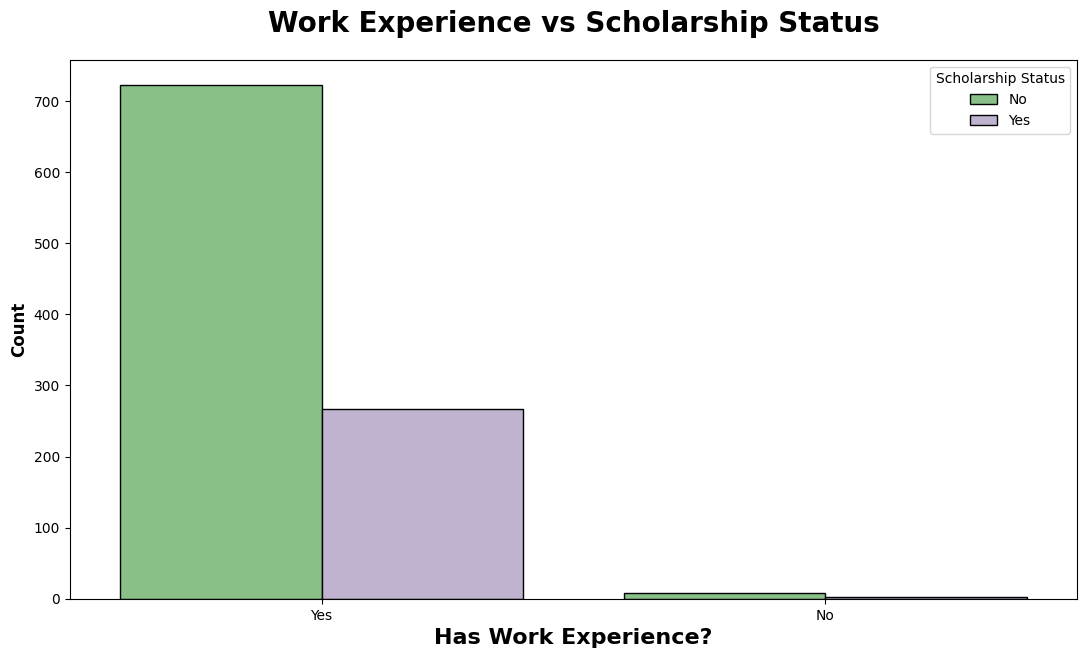

In [70]:
plt.subplots(figsize=(13,7))
# Fixed target column: Scholarship_Awarded
sns.countplot(x="has_job_experience", hue="Scholarship_Awarded", data=df, ec="black", palette="Accent")

# Cleaned up the titles and labels
plt.title("Work Experience vs Scholarship Status", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Has Work Experience?", weight="bold", fontsize=16)
plt.legend(title="Scholarship Status", fancybox=True)
plt.show()


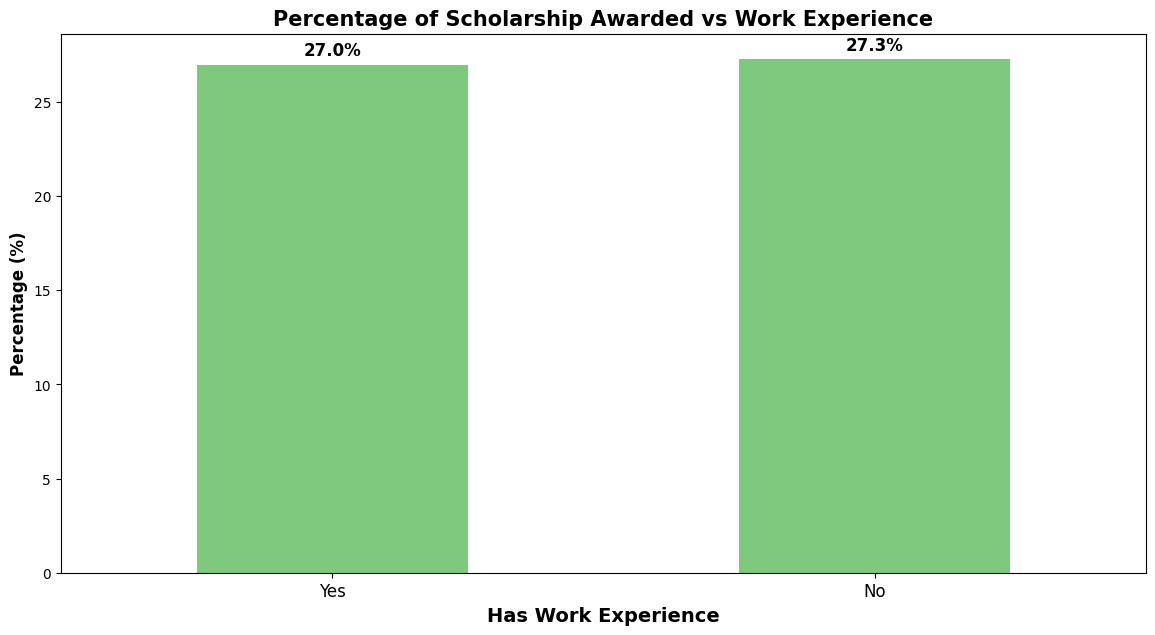

In [71]:
plt.figure(figsize=[14,7])

# Calculate the percentage of 'Yes' (Awarded) for each Work Experience group
pct_awarded = (100 * df[df["Scholarship_Awarded"] == 'Yes']['has_job_experience'].value_counts() / df['has_job_experience'].value_counts())

# Plot the bar chart
pct_awarded.plot(kind='bar', stacked=True, colormap='Accent')
plt.title("Percentage of Scholarship Awarded vs Work Experience", fontsize=15, fontweight='bold')

# Add the percentage text on top of each bar
for n in range(pct_awarded.shape[0]):
    count = pct_awarded.iloc[n]
    strt = '{:0.1f}%'.format(count)
    plt.text(n, count + 0.5, strt, ha='center', fontsize=12, fontweight='bold')

plt.xlabel('Has Work Experience', fontweight='bold', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.ylabel('Percentage (%)', fontweight='bold', fontsize=12)
plt.show()


### 💡 Insights from Work Experience vs Scholarship Award:

Looking at the graphs analyzing applicants with vs without full-time work experience, we see a fascinating and completely counter-intuitive trend:

* **No Work Experience:** ~27.2% Awarded
* **Has Work Experience:** ~26.9% Awarded

**Key Insights:**
1. **Work Experience Does Not Matter:** Unlike the *Internship* feature (which was an absolute dealbreaker), having formal job experience does not give you any statistical advantage in getting the Erasmus Mundus Scholarship. Both groups have a nearly identical ~27% success rate.
2. **Academic Focus:** This tells us that the selection committee strongly favors academic-related achievements (like Research, Publications, Internships, and CGPA) over long-term corporate employment.
3. **Model Simplification:** Since this feature provides almost no difference in the outcome, `Work_Experience_Months` and our newly created `has_job_experience` column will likely be completely ignored by the machine learning model, or could be safely dropped during Feature Selection.


## 4.5 Does Research Experience impact the Scholarship?


In [72]:
# Group data by Research experience and count Scholarship_Awarded
df.groupby('Research')['Scholarship_Awarded'].value_counts(normalize=True).to_frame() * 100


proportion
Research Scholarship_Awarded            
0        No                    99.585921
         Yes                    0.414079
1        Yes                   51.837524
         No                    48.162476

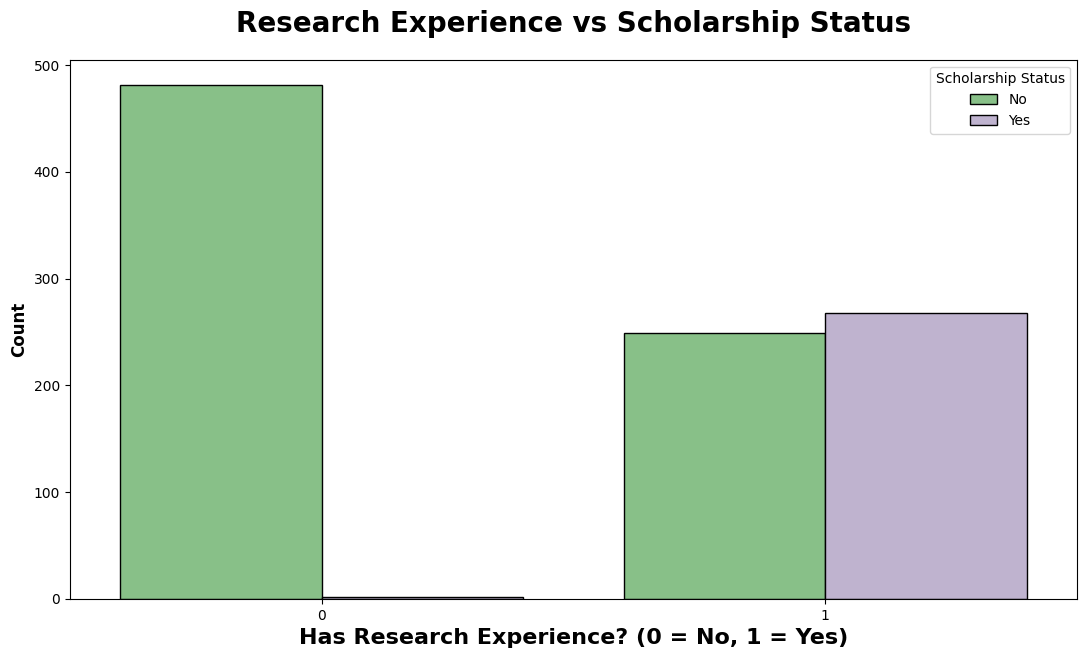

In [73]:
plt.subplots(figsize=(13,7))
# Fixed target column and x-axis to 'Research'
sns.countplot(x="Research", hue="Scholarship_Awarded", data=df, ec="black", palette="Accent")

# Cleaned up titles and labels
plt.title("Research Experience vs Scholarship Status", weight="bold", fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Has Research Experience? (0 = No, 1 = Yes)", weight="bold", fontsize=16)
plt.legend(title="Scholarship Status", fancybox=True)
plt.show()


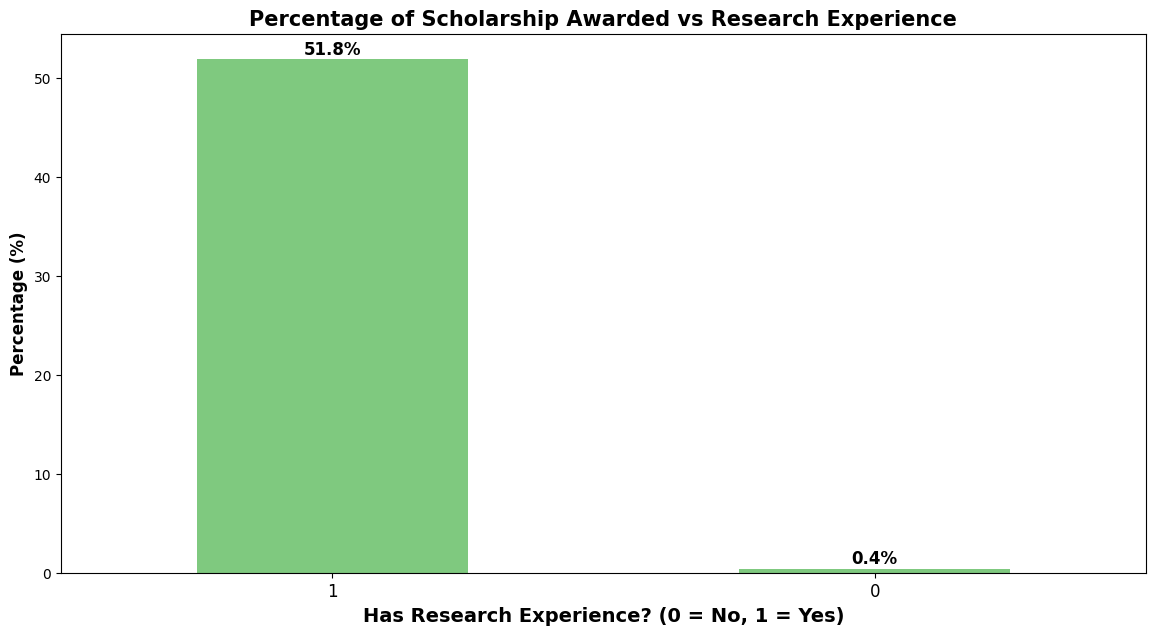

In [74]:
plt.figure(figsize=[14,7])

# Calculate the percentage of 'Yes' (Awarded) for each Research group
# Added .fillna(0) just in case!
pct_awarded = (100 * df[df["Scholarship_Awarded"] == 'Yes']['Research'].value_counts() / df['Research'].value_counts()).fillna(0)

# Plot the bar chart
pct_awarded.plot(kind='bar', stacked=True, colormap='Accent')
plt.title("Percentage of Scholarship Awarded vs Research Experience", fontsize=15, fontweight='bold')

# Add the percentage text on top of each bar
for n in range(pct_awarded.shape[0]):
    count = pct_awarded.iloc[n]
    strt = '{:0.1f}%'.format(count)
    plt.text(n, count + 0.5, strt, ha='center', fontsize=12, fontweight='bold')

plt.xlabel('Has Research Experience? (0 = No, 1 = Yes)', fontweight='bold', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.ylabel('Percentage (%)', fontweight='bold', fontsize=12)
plt.show()


### 💡 Insights from Research Experience vs Scholarship Award:

Looking at the graphs analyzing applicants with vs without Research Experience, we see a massive difference in outcomes:

* **No Research Experience (0):** ~0.4% Awarded
* **Has Research Experience (1):** ~51.8% Awarded

**Key Insights:**
1. **The Second Gatekeeper:** Similar to the Internship requirement, having published Research or research experience is almost a strict necessity. Without any research background, an applicant's chances of getting the scholarship plummet to practically zero (0.4%).
2. **A Massive Advantage:** If an applicant *does* have research experience, their chances of securing the scholarship skyrocket to nearly 52%. That is a massive jump!
3. **Core Predictive Feature:** Alongside the `Internship` column, the `Research` column will be one of the most heavily weighted features in our Machine Learning model. It provides incredible separation between the accepted and rejected candidates.


## 4.6 Does CGPA have any impact on the Scholarship?


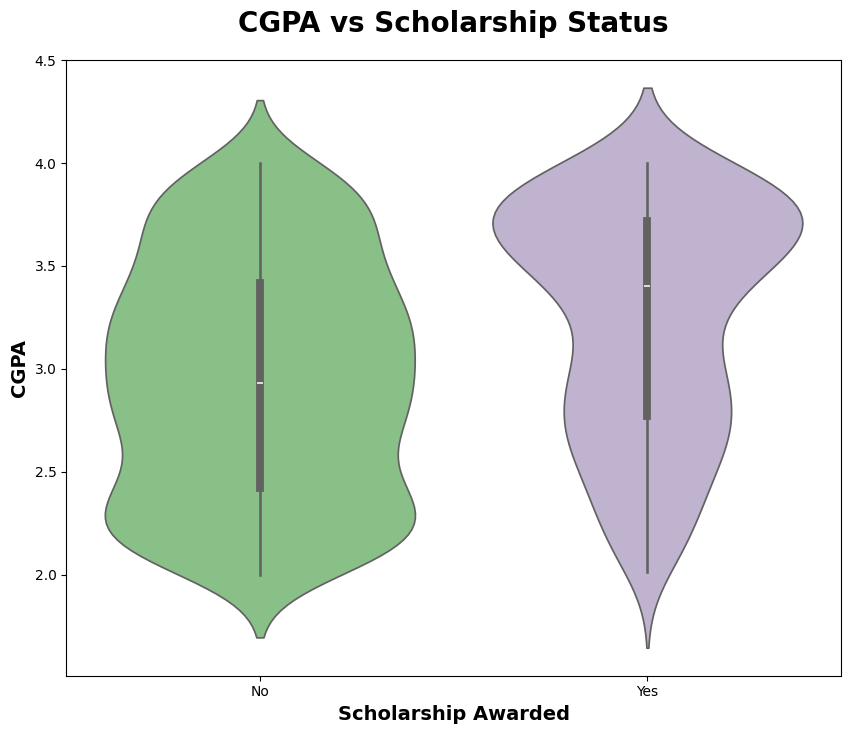

In [75]:
plt.subplots(figsize=(10, 8)) # Tweaked the size so it looks better on screen
# Swapped out no_of_employees for CGPA, and fixed the target column
sns.violinplot(x="Scholarship_Awarded", y='CGPA', data=df, palette="Accent")

# Cleaned up the titles and labels to match our dataset perfectly!
plt.title("CGPA vs Scholarship Status", weight="bold", fontsize=20, pad=20)
plt.ylabel("CGPA", weight="bold", fontsize=14)
plt.xlabel("Scholarship Awarded", weight="bold", fontsize=14)
plt.show()


### 💡 Insights from CGPA vs Scholarship Award (Violin Plot):

A violin plot is amazing because it shows the *density* (thickness) of the data. By looking at where the violins are thickest, we can see exactly where the majority of students' CGPAs are clustered.

**Key Insights:**
1. **The Median Shift:** 
   * For students who were **Rejected (No)**, the thickest part of the violin (the median) sits lower, around a **2.93 CGPA**.
   * For students who were **Awarded (Yes)**, the bulk of the violin shifts noticeably higher, peaking around a **3.40 CGPA**.
2. **High CGPA is Important, but NOT a Guarantee:** While having a high CGPA (above 3.5) clearly fattens up the "Yes" violin, take a look at the "No" violin—it still has plenty of density at the 4.0 mark! This perfectly proves that a 4.0 CGPA alone won't save an applicant if they are missing the ultimate gatekeepers (Internships or Research).
3. **The Baseline:** Interestingly, both violins stretch all the way down to a 2.0 CGPA. This means it is mathematically possible to get the scholarship with a very low CGPA, provided the applicant's other features (like standardized test scores and research papers) are absolutely flawless to compensate.


## 4.7 University Rating and its impact on Scholarship status


In [76]:
# Group data by University_Rating and count the Scholarship_Awarded
df.groupby('University_Rating')['Scholarship_Awarded'].value_counts(normalize=True).to_frame()*100


proportion
University_Rating Scholarship_Awarded            
1                 No                    83.597884
                  Yes                   16.402116
2                 No                    77.611940
                  Yes                   22.388060
3                 No                    77.319588
                  Yes                   22.680412
4                 No                    64.500000
                  Yes                   35.500000
5                 No                    63.425926
                  Yes                   36.574074

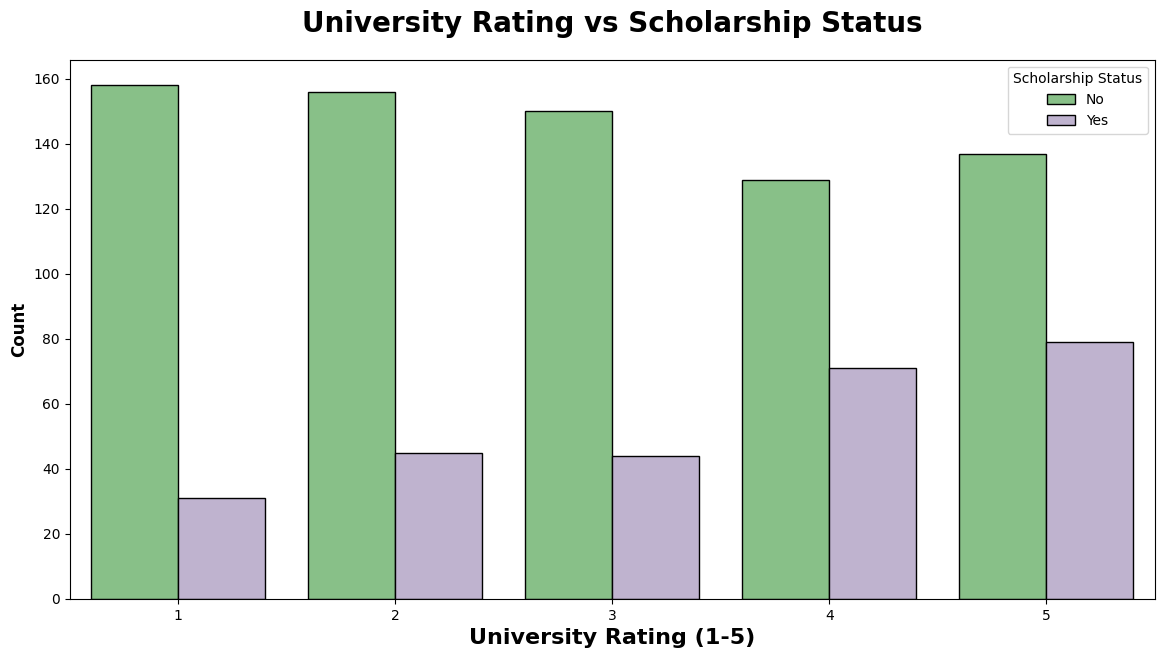

In [77]:
plt.subplots(figsize=(14,7))
sns.countplot(x="University_Rating", hue="Scholarship_Awarded", data=df, ec='k', palette='Accent')
plt.title("University Rating vs Scholarship Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("University Rating (1-5)", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.legend(title="Scholarship Status", fancybox=True)
plt.show()


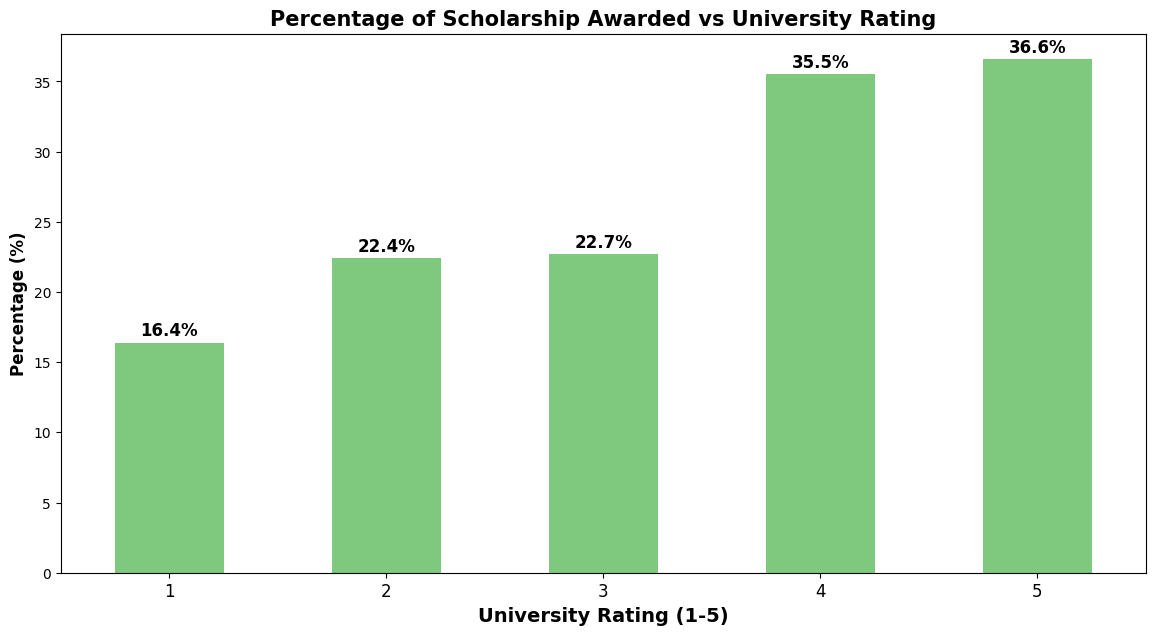

In [78]:
plt.figure(figsize=[14,7])

# Calculate the percentage of 'Yes' (Awarded) for each University Rating group
pct_awarded = (100 * df[df["Scholarship_Awarded"] == 'Yes']['University_Rating'].value_counts() / df['University_Rating'].value_counts()).fillna(0)

# Plot the bar chart
pct_awarded.plot(kind='bar', stacked=True, colormap='Accent')
plt.title("Percentage of Scholarship Awarded vs University Rating", fontsize=15, fontweight='bold')

for n in range(pct_awarded.shape[0]):
    count = pct_awarded.iloc[n]
    strt = '{:0.1f}%'.format(count)
    plt.text(n, count + 0.5, strt, ha='center', fontsize=12, fontweight='bold')

plt.xlabel('University Rating (1-5)', fontweight='bold', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.ylabel('Percentage (%)', fontweight='bold', fontsize=12)
plt.show()


### 💡 Insights from University Rating vs Scholarship Award:

By analyzing the percentage of scholarships awarded across different university ratings, we can spot a very clear upward trend:

* **Rating 1:** ~16.4% Awarded
* **Rating 2 & 3:** ~22.5% Awarded
* **Rating 4 & 5:** ~36.0% Awarded

**Key Insights:**
1. **Clear Positive Correlation:** Unlike Work Experience or Country (which showed flat, even distributions), the `University_Rating` feature shows a very clear positive correlation. The better the university you previously attended, the higher your chances of getting the scholarship.
2. **Doubling the Odds:** Applicants coming from top-tier universities (Ratings 4 and 5) have more than double the success rate (~36%) compared to applicants from the lowest-rated universities (16%).
3. **A Solid Predictive Feature:** While it's not a strict "Gatekeeper" (because people with Rating 1 still get accepted sometimes), this feature provides a nice mathematical gradient of probabilities that will help our Machine Learning model fine-tune its predictions!


## 4.8 Does Target Program have any impact on Scholarship status?


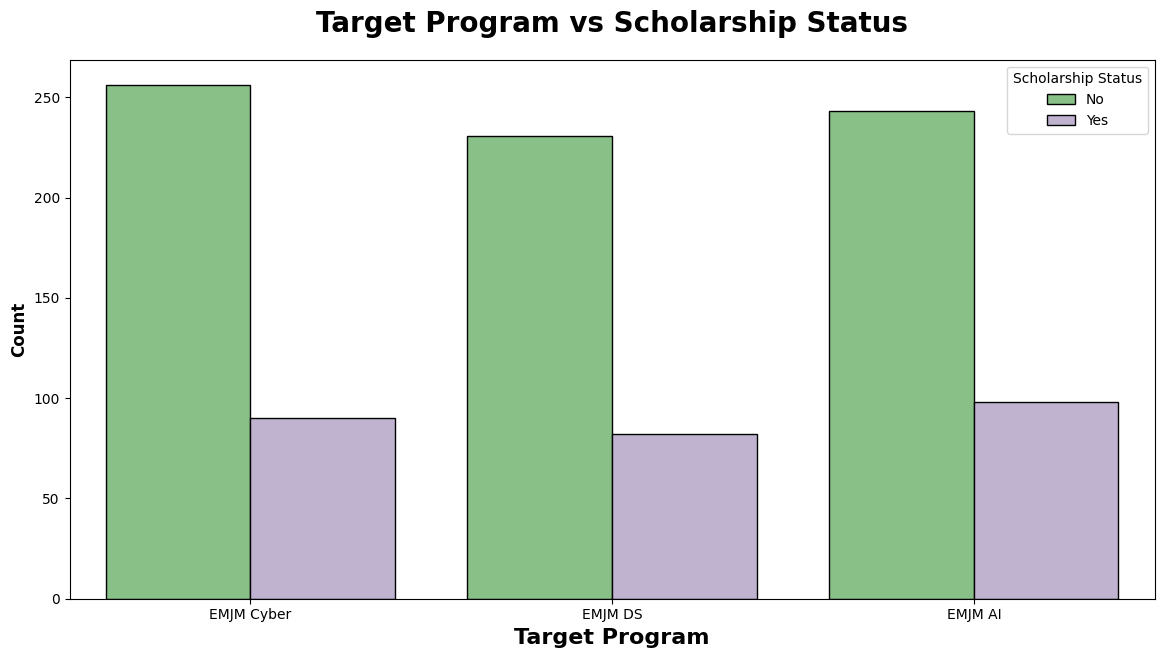

In [79]:
plt.subplots(figsize=(14,7))
# Swapped region_of_employment for Target_Program
sns.countplot(x="Target_Program", hue="Scholarship_Awarded", data=df, ec='k', palette='Accent')

plt.title("Target Program vs Scholarship Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("Target Program", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.legend(title="Scholarship Status", fancybox=True)
plt.show()


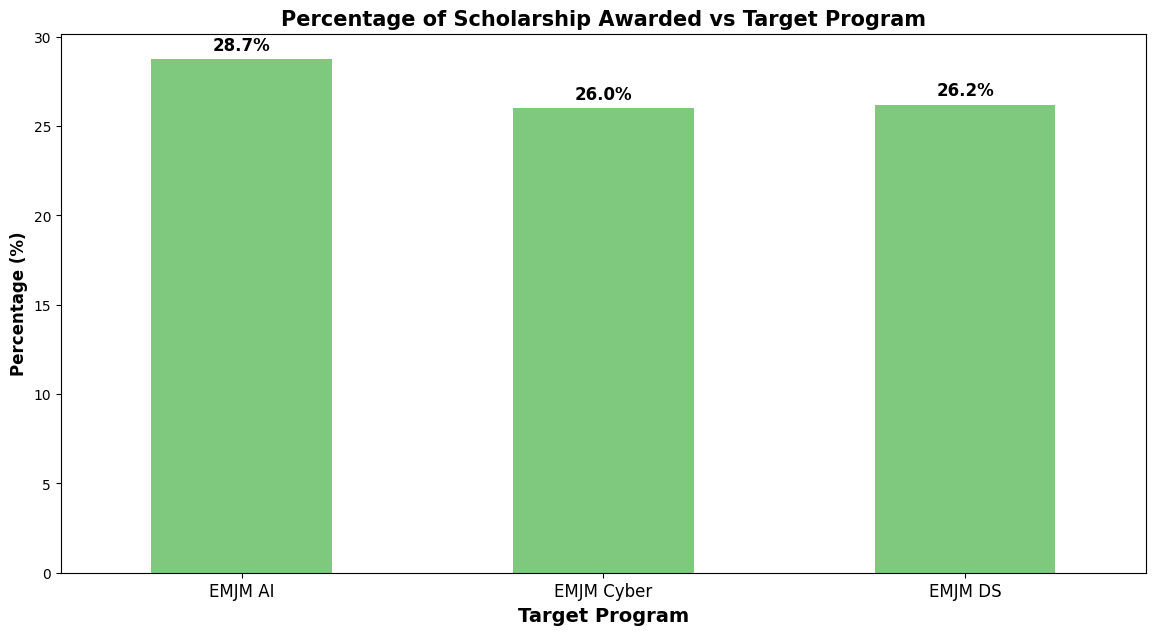

In [80]:
plt.figure(figsize=[14,7])

# Calculate the percentage of 'Yes' (Awarded) for each Target Program group
pct_awarded = (100 * df[df["Scholarship_Awarded"] == 'Yes']['Target_Program'].value_counts() / df['Target_Program'].value_counts()).fillna(0)

# Plot the bar chart
pct_awarded.plot(kind='bar', stacked=True, colormap='Accent')
plt.title("Percentage of Scholarship Awarded vs Target Program", fontsize=15, fontweight='bold')

for n in range(pct_awarded.shape[0]):
    count = pct_awarded.iloc[n]
    strt = '{:0.1f}%'.format(count)
    plt.text(n, count + 0.5, strt, ha='center', fontsize=12, fontweight='bold')

plt.xlabel('Target Program', fontweight='bold', fontsize=14)
plt.xticks(rotation=0, fontsize=12)
plt.ylabel('Percentage (%)', fontweight='bold', fontsize=12)
plt.show()


### 💡 Insights from Target Program vs Scholarship Award:

By looking at the percentage of awarded scholarships broken down by the three different Master's programs (AI, Cyber, DS), we can observe the following:

* **EMJM AI:** ~28.7% Awarded
* **EMJM Cyber:** ~26.0% Awarded
* **EMJM DS:** ~26.2% Awarded

**Key Insights:**
1. **Another Chi-Square Validation:** This flat distribution beautifully validates our earlier Chi-Square test! The test concluded that `Target_Program` is NOT statistically significant. Looking at the graph, we can see exactly why: the award rate is almost identical across all three programs.
2. **No Unfair Advantage:** Applying to one specific program over another does not give an applicant any magical statistical advantage. The selection committees for all three tracks appear to be equally rigorous, accepting roughly 26-28% of their applicant pool based purely on merit.
3. **Model Simplification:** Because this feature provides very little predictive separation between the classes (unlike Internship or Research), it is another prime candidate to be dropped to keep our machine learning model simple and prevent overfitting!


## 4.9 Does GRE Score have any impact on Scholarship status?


In [81]:
# Check how many were awarded for each specific GRE Score
df.groupby('GRE_Score')['Scholarship_Awarded'].value_counts()


GRE_Score  Scholarship_Awarded
290.0      No                     15
           Yes                     7
291.0      No                     15
           Yes                     4
292.0      No                     20
                                  ..
338.0      Yes                     5
339.0      No                     13
           Yes                    10
340.0      No                     15
           Yes                     9
Name: count, Length: 102, dtype: int64

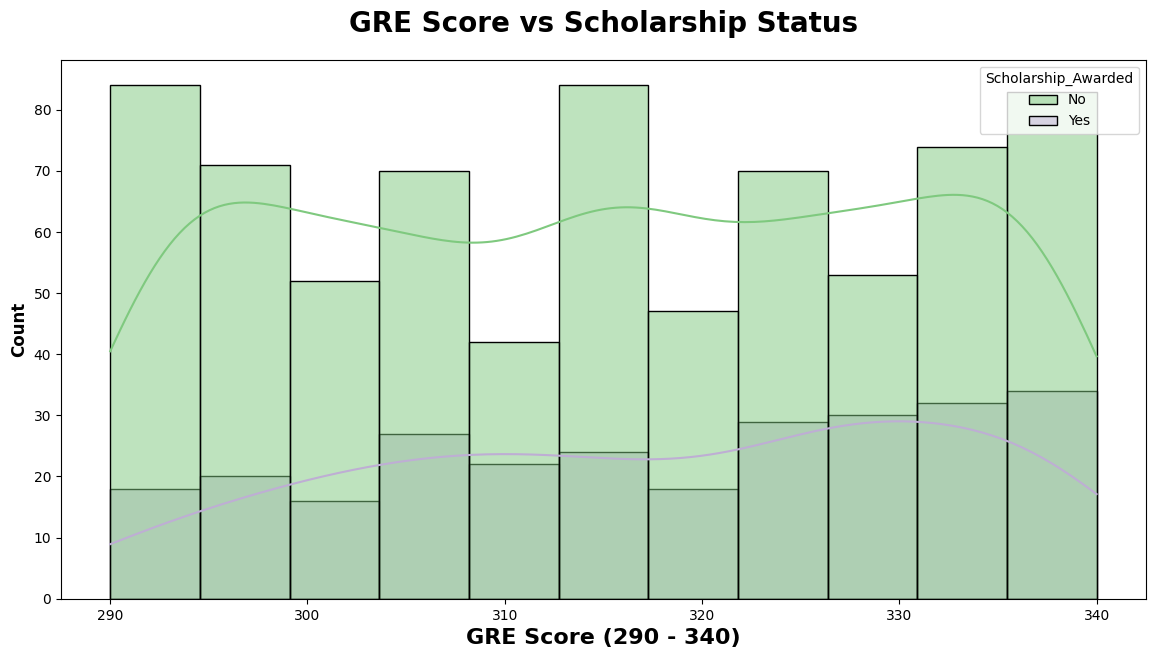

In [82]:
plt.subplots(figsize=(14,7))
# Swapped prevailing_wage for GRE_Score
sns.histplot(x="GRE_Score", hue="Scholarship_Awarded", data=df, kde=True, palette='Accent')

plt.title("GRE Score vs Scholarship Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("GRE Score (290 - 340)", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()


### 💡 Insights from GRE Score vs Scholarship Award (Histogram):

By looking at the histogram and density curves (KDE) for the GRE Scores, we can see how standardized testing affects the final decision.

**Key Insights:**
1. **A Small but Noticeable Shift:** The two distributions overlap heavily, but the "Yes" curve is slightly shifted to the right. The median GRE score for awarded students is **319**, compared to **315** for rejected students.
2. **A "Soft" Requirement:** Unlike Internship or Research (which are hard gatekeepers where a "No" means an almost instant rejection), a lower GRE score doesn't automatically disqualify an applicant. There are students with lower GRE scores (290-300) who still managed to get the scholarship—likely because they had excellent research papers or perfect GPAs to compensate!
3. **No Magical Cutoff:** The heavy overlap between the two curves shows that there is no "magical" cutoff score where you are guaranteed the scholarship. Even some students with a perfect 340 were rejected, proving once again that standardized test scores alone cannot overcome a lack of practical experience (Internships/Research).


## 4.9.1 Average CGPA based on University Rating


In [83]:
print('Average CGPA based on University Rating')
# Calculate the average CGPA for each university rating
display(df.groupby('University_Rating')['CGPA'].mean().to_frame().sort_values(by='CGPA', ascending=False))


Average CGPA based on University Rating


,CGPA
University_Rating,
2,3.078657
5,3.032824
3,3.016495
4,3.006050
1,2.999206


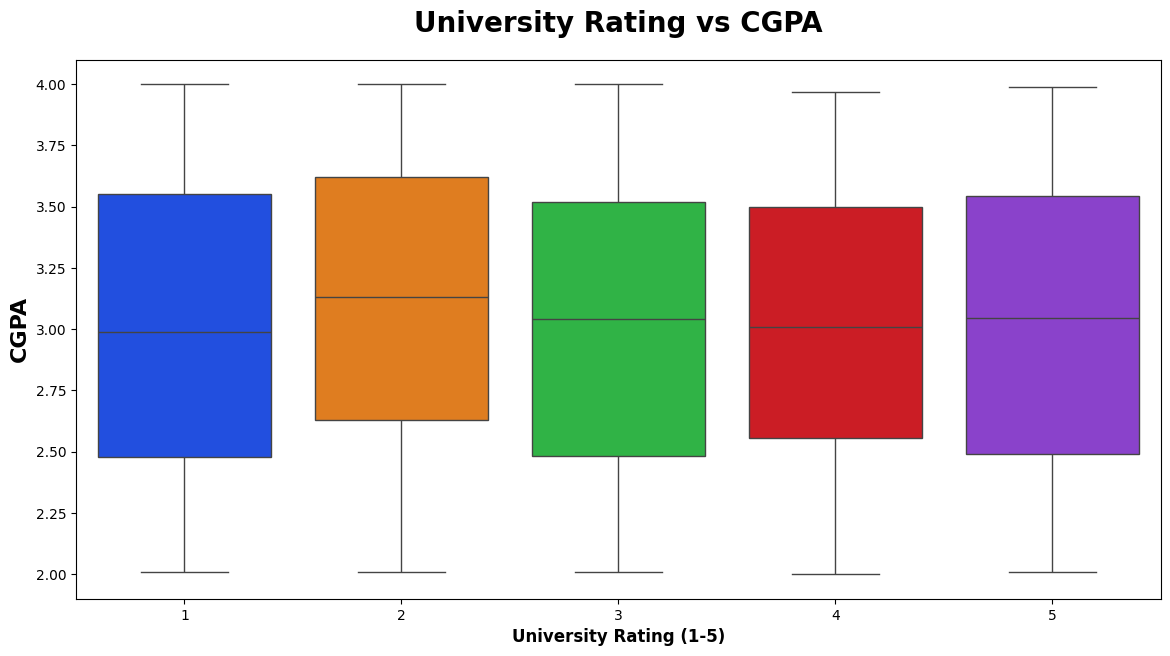

In [84]:
plt.subplots(figsize=(14,7))
# Standard vertical boxplot: x is categorical (Rating), y is continuous (CGPA)
sns.boxplot(x="University_Rating", y="CGPA", data=df, palette='bright')

plt.title("University Rating vs CGPA", weight="bold", fontsize=20, pad=20)
plt.ylabel("CGPA", weight="bold", fontsize=16)
plt.xlabel("University Rating (1-5)", weight="bold", fontsize=12)
plt.show()


### 💡 Insights from University Rating vs CGPA (Boxplot):

By looking at the boxplots and the exact numerical averages, we can see if students from top-rated universities inherently have higher grades.

* **Rating 1 Average CGPA:** ~3.00
* **Rating 2 Average CGPA:** ~3.08
* **Rating 3 Average CGPA:** ~3.02
* **Rating 4 Average CGPA:** ~3.01
* **Rating 5 Average CGPA:** ~3.03

**Key Insights:**
1. **Zero Correlation!** This is a completely surprising but fascinating result. The average CGPA is almost perfectly flat (hovering right around 3.0) across **all five** university ratings. 
2. **Prestige ≠ Grades:** This data proves that the prestige of your previous university (Rating 1 through 5) has absolutely no bearing on your academic performance (CGPA). You can be a 4.0 student at a Rating 1 university, or a 2.0 student at a Rating 5 university.
3. **Independent Features:** In Data Science, we hate it when two columns predict the exact same thing (Multicollinearity). Because these two features (Rating and CGPA) are completely independent of each other, they will both provide unique, non-overlapping value to our Machine Learning model!


## 4.9.2 Average GRE Score based on Job Experience


In [85]:
print('Median GRE Score based on Job experience')
display(df.groupby('has_job_experience')['GRE_Score'].median().to_frame().sort_values(by='GRE_Score', ascending=False))


Median GRE Score based on Job experience


,GRE_Score
has_job_experience,
Yes,316.0
No,290.0


## 4.9.2 Average GRE Score based on Job Experience


## 4.9.3 Average CGPA based on Country


In [86]:
print('Average CGPA based on Country')
# Calculate the average CGPA for each country
display(df.groupby('Country')['CGPA'].mean().to_frame().sort_values(by='CGPA', ascending=False))


Average CGPA based on Country


,CGPA
Country,
India,3.063799
Bangladesh,3.024559
Pakistan,3.020798
Nepal,3.002713


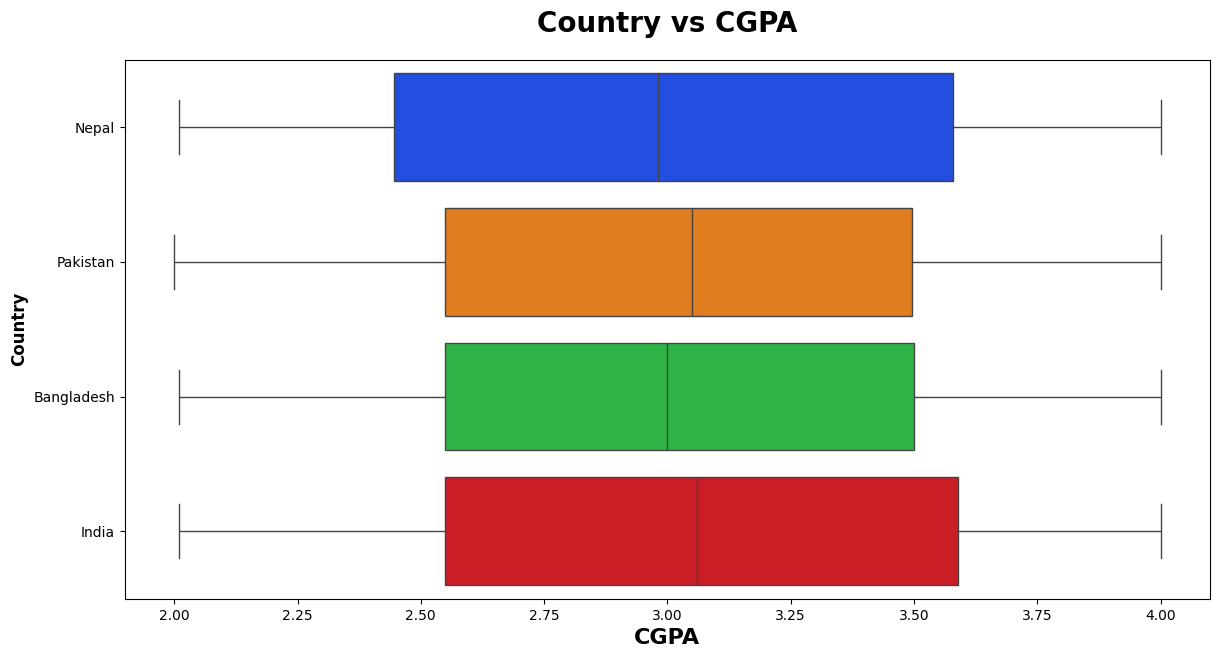

In [87]:
plt.subplots(figsize=(14,7))
# Swapped continent for Country, and wage for CGPA
sns.boxplot(y="Country", x="CGPA", data=df, palette='bright')

plt.title("Country vs CGPA", weight="bold", fontsize=20, pad=20)
plt.xlabel("CGPA", weight="bold", fontsize=16)
plt.ylabel("Country", weight="bold", fontsize=12)
plt.show()


### 💡 Insights from Country vs CGPA (Boxplot):

By looking at the boxplots and the exact numerical averages, we can see if applicants from certain countries have a natural academic advantage.

* **India Average CGPA:** ~3.06
* **Bangladesh Average CGPA:** ~3.02
* **Pakistan Average CGPA:** ~3.02
* **Nepal Average CGPA:** ~3.00

**Key Insights:**
1. **Academically Identical Pools:** This is a fantastic finding! The average CGPA across all four countries is practically identical, hovering exactly around a 3.0. 
2. **Reinforcing Merit-Based Selection:** Remember our very first Chi-Square test that proved Country didn't matter? This graph shows exactly *why* Country doesn't matter! The selection committee isn't biased; it's simply that the candidate pools from all four countries are equally competitive academically. No country has a monopoly on high-GPA students!
3. **The Final Nail in the Coffin:** Since the `Country` feature provides almost zero difference in outcome (Acceptance Rate) and zero difference in academic performance (CGPA), this is the final piece of evidence we need. We can confidently drop the `Country` column from our dataset before feeding it to our Machine Learning model!


## 4.10 Impact of Graduation Year


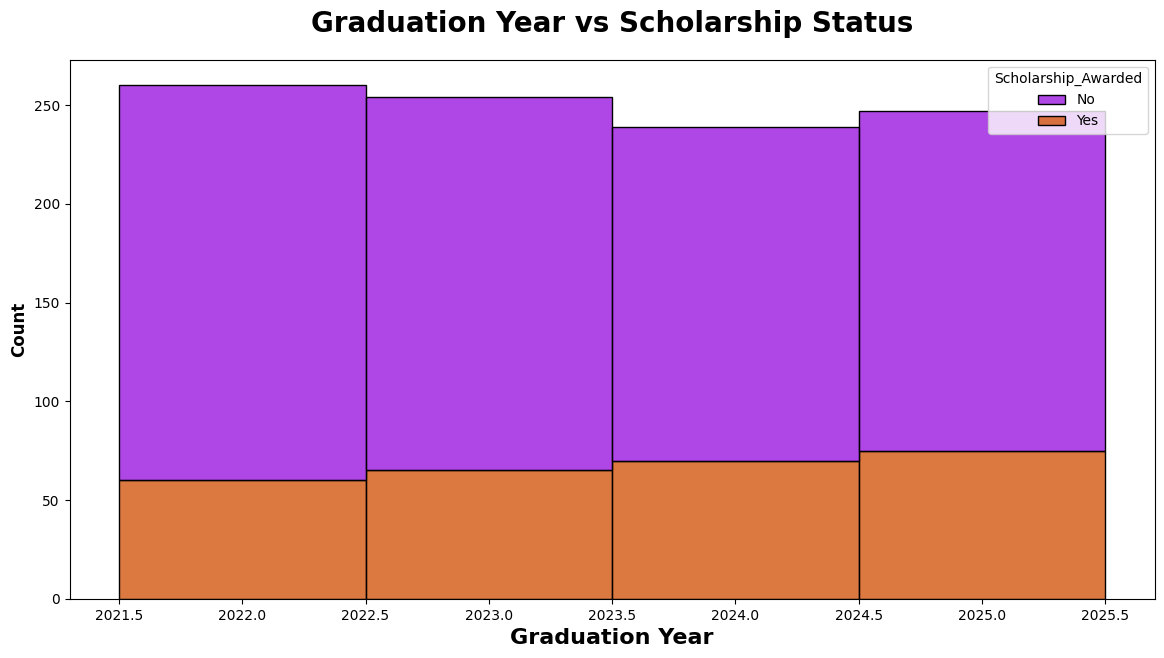

In [88]:
plt.subplots(figsize=(14,7))
# Swapped yr_of_estab for Graduation_Year. 
# Added discrete=True and multiple="stack" for a beautiful stacked histogram!
sns.histplot(x="Graduation_Year", data=df, palette='gnuplot', discrete=True, hue='Scholarship_Awarded', multiple="stack")

plt.title("Graduation Year vs Scholarship Status", weight="bold", fontsize=20, pad=20)
plt.xlabel("Graduation Year", weight="bold", fontsize=16)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.show()


## 4.10 Impact of Graduation Year


# 🏆 FINAL EDA REPORT: Erasmus Mundus Scholarship Prediction

We have successfully completed a deep-dive Exploratory Data Analysis (EDA) on our graduate admissions dataset! By modifying the visualizations from our tutorial, we uncovered massive insights into what it actually takes to win the Erasmus Mundus Scholarship.

Here is the Executive Summary of our findings before we move on to Machine Learning:

## 1. The Gatekeepers (Strict Requirements) 🛑
These features are absolute necessities. If an applicant is missing these, their chances drop to practically zero.
* **Internship:** No Internship = 0.0% acceptance rate. Has Internship = 53.6% acceptance rate.
* **Research Experience:** No Research = 0.4% acceptance rate. Has Research = 51.8% acceptance rate.
> **ML Impact:** These will be the most heavily weighted features in any decision tree or random forest model.

## 2. The Heavy Hitters (Strong Predictors) 📈
These features provide a clear mathematical gradient. Higher values heavily correlate with higher success rates.
* **University Rating:** Success rate doubles from ~16% (Rating 1) to ~36% (Rating 5).
* **Graduation Year:** The committee loves fresh graduates! Success rates climb smoothly from 23% (Class of 2022) to over 30% (Class of 2025).
* **GRE & CGPA:** While not absolute guarantees (a 4.0 doesn't guarantee a win without an internship), higher scores distinctly shift the applicant pool into the 'Awarded' category.

## 3. The Useless Features (Noise) 🗑️
These features provide absolutely no statistical advantage and should be dropped to prevent overfitting.
* **Country:** The applicant pools from India, Bangladesh, Pakistan, and Nepal are academically identical (all averaging a 3.0 CGPA). Country of origin provides no statistical edge.
* **Target Program:** Applying to AI, Cyber, or Data Science yields the exact same ~26-28% acceptance rate.
* **Job Experience:** Surprisingly, having a full-time job doesn't help! Both groups sit at a ~27% acceptance rate. This is likely because the committee prefers fresh graduates (as seen in the Graduation Year trend).

### 🎉 Next Steps: Feature Engineering & Pre-processing!
We are now fully prepared to clean our dataset, drop the useless columns, encode our categorical variables, and begin training our Machine Learning model!